# Localisation
Integrated RIVA v4 localisation with classifier-gated final point predictions.


# RIVA v4 localisation method + classifier integration

This notebook intentionally follows the stronger `riva_localisation_v4` workflow for localisation: percentage keypoints, paired image/heatmap augmentation, sigma-10 Gaussian targets, focal-Tversky-MSE loss, validation AP monitoring, and TTA evaluation.

The binary classification model is kept integrated through a lightweight classifier probability gate during validation/testing, instead of feature-fusing into the heatmap network. This avoids the corner/whole-image activation issue while still using the classifier to suppress unlikely localisation outputs.


# RIVA Localisation — V4 Boosted Fair Comparison

V4 clean/boosted rebuild for comparing **U-Net** and **Stacked Hourglass** on RIVA cell localisation.

This version is intentionally self-contained: run from the top on a fresh kernel. It uses identical data splits, paired image/heatmap augmentations, tuning logic, final training logic, checkpointing, timing logs, and evaluation metrics for both models.


## What this code does

- Builds localisation heatmaps for precancerous cell points.
- Trains U-Net and Stacked Hourglass fairly.
- Keeps the Stacked Hourglass tuning style and maps U-Net width via `base = channels`.
- Separates hyperparameter tuning from final training.
- Saves checkpoints every epoch so long runs can resume after crashes.
- Uses a fresh experiment tag so old checkpoints are ignored.
- Reports AP/mAP, calibrated threshold metrics, Dice, IoU, F1, PCK, and runtime.


In [1]:
from pathlib import Path

# EDIT THIS: path to your local riva_1.0 folder
DATASET_PATH = r"C:\Users\Admin\Downloads\riva_1.0"

# Outputs are shared across notebooks so the Results notebook can load them later.
OUTPUT_ROOT = Path(DATASET_PATH).parent / "riva_outputs"
BASE_DIR = Path(DATASET_PATH)
IMG_DIR = BASE_DIR / "images"
ANNOT_FILE = BASE_DIR / "annotations" / "annotations.json"
MODEL_DIR_PATH = OUTPUT_ROOT / "saved_models"
RESULTS_DIR_PATH = OUTPUT_ROOT / "results"
FIG_DIR_PATH = OUTPUT_ROOT / "figures"
for p in [MODEL_DIR_PATH, RESULTS_DIR_PATH, FIG_DIR_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("Paths configured:")
print(f"  Dataset     : {BASE_DIR}  ({'OK' if BASE_DIR.exists() else 'MISSING - check DATASET_PATH'})")
print(f"  Images      : {IMG_DIR}  ({'OK' if IMG_DIR.exists() else 'MISSING'})")
print(f"  Annotations : {ANNOT_FILE}  ({'OK' if ANNOT_FILE.exists() else 'MISSING'})")
print(f"  Models out  : {MODEL_DIR_PATH}")
print(f"  Results out : {RESULTS_DIR_PATH}")


Paths configured:
  Dataset     : C:\Users\Admin\Downloads\riva_1.0  (OK)
  Images      : C:\Users\Admin\Downloads\riva_1.0\images  (OK)
  Annotations : C:\Users\Admin\Downloads\riva_1.0\annotations\annotations.json  (OK)
  Models out  : C:\Users\Admin\Downloads\riva_outputs\saved_models
  Results out : C:\Users\Admin\Downloads\riva_outputs\results


In [2]:
import os, json, random, time, datetime, gc
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SIZE = 224
BATCH_SIZE = 32
IMG_EXTS = ['.png', '.jpg', '.jpeg', '.bmp']

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [3]:
BINARY_CLASSES = ['NON_LESION', 'PRECANCEROUS']
NUM_BINARY = 2
BINARY_MAPPING = {
    'SCC':'PRECANCEROUS', 'HSIL':'PRECANCEROUS', 'ASCH':'PRECANCEROUS',
    'LSIL':'PRECANCEROUS', 'ASCUS':'PRECANCEROUS',
    'INFL':'NON_LESION', 'ENDO':'NON_LESION', 'NILM':'NON_LESION'
}

CLASS_NAMES_6 = ['ASCUS', 'LSIL', 'ASCH', 'HSIL', 'SCC', 'INFL']
CLASS_NAMES_7 = ['ASCUS', 'LSIL', 'ASCH', 'HSIL', 'SCC', 'INFL', 'ENDO']
CLASS_NAMES_8 = ['ASCUS', 'LSIL', 'ASCH', 'HSIL', 'SCC', 'INFL', 'ENDO', 'NILM']
PRIORITY_6 = ['SCC', 'HSIL', 'ASCH', 'ASCUS', 'LSIL', 'INFL']
PRIORITY_7 = ['SCC', 'HSIL', 'ASCH', 'ASCUS', 'LSIL', 'INFL', 'ENDO']
PRIORITY_8 = ['SCC', 'HSIL', 'ASCH', 'ASCUS', 'LSIL', 'INFL', 'ENDO', 'NILM']

with open(ANNOT_FILE, 'r', encoding='utf-8') as f:
    riva_annots = json.load(f)

def normalise_label(label):
    """Normalise one RIVA/Label Studio label.

    Important fix: Label Studio sometimes stores keypointlabels as a list,
    e.g. ['LSIL'], not a plain string. The old code converted the list to
    the string "['LSIL']", so localisation labels could be silently missed.
    """
    if label is None:
        return ''
    if isinstance(label, (list, tuple, set)):
        # Prefer known labels if more than one is present.
        for v in label:
            nv = normalise_label(v)
            if nv in {'ASCUS', 'LSIL', 'ASCH', 'HSIL', 'SCC', 'INFL', 'ENDO', 'NILM'}:
                return nv
        return normalise_label(next(iter(label), ''))
    if isinstance(label, dict):
        for k in ('value', 'label', 'name'):
            if k in label:
                return normalise_label(label[k])
    lbl = str(label).strip().upper()
    lbl = lbl.replace('[', '').replace(']', '').replace("'", '').replace('\"', '')
    lbl = lbl.replace('-', '').replace('_', '').strip()
    alias = {
        'ENDOCERVICAL': 'ENDO',
        'ENDOCERVICAL CELL': 'ENDO',
        'ENDOCERVICAL CELLS': 'ENDO',
        'INFLAMMATION': 'INFL',
        'INFLAMMATORY': 'INFL',
        'ASC H': 'ASCH',
        'ASC-H': 'ASCH',
        'ASCUS': 'ASCUS',
        'LSIL': 'LSIL',
        'HSIL': 'HSIL',
        'ASCH': 'ASCH',
        'SCC': 'SCC',
        'INFL': 'INFL',
        'ENDO': 'ENDO',
        'NILM': 'NILM',
    }
    return alias.get(lbl, lbl)


def labels_from_keypoint(kp):
    """Return all normalised labels attached to one annotation point."""
    raw = None
    for key in ('keypointlabels', 'keypointLabels', 'labels', 'label', 'class', 'category'):
        if isinstance(kp, dict) and key in kp:
            raw = kp.get(key)
            break
    if raw is None:
        return []
    if isinstance(raw, (list, tuple, set)):
        return [normalise_label(v) for v in raw if normalise_label(v)]
    return [normalise_label(raw)] if normalise_label(raw) else []

def _main_multiclass_label(raw_labels, class_names, priority):
    mc_labels = raw_labels & set(class_names)
    if not mc_labels:
        return None
    return next((p for p in priority if p in mc_labels), None)

dataset_items = []
for img_name, ann_data in riva_annots.items():
    raw_labels = set()
    for ann_kps in ann_data.values():
        if not isinstance(ann_kps, list):
            continue
        for kp in ann_kps:
            for lbl in labels_from_keypoint(kp):
                if lbl in set(CLASS_NAMES_8):
                    raw_labels.add(lbl)
    if not raw_labels:
        continue

    img_path = next((IMG_DIR / f"{img_name}{e}" for e in IMG_EXTS if (IMG_DIR / f"{img_name}{e}").exists()), None)
    if img_path is None:
        continue

    binary_set = {BINARY_MAPPING[l] for l in raw_labels if l in BINARY_MAPPING}
    label_vector = [1 if cls in binary_set else 0 for cls in BINARY_CLASSES]
    binary_label = 1 if 'PRECANCEROUS' in binary_set else 0

    mc6 = _main_multiclass_label(raw_labels, CLASS_NAMES_6, PRIORITY_6)
    mc7 = _main_multiclass_label(raw_labels, CLASS_NAMES_7, PRIORITY_7)
    mc8 = _main_multiclass_label(raw_labels, CLASS_NAMES_8, PRIORITY_8)

    dataset_items.append({
        'img_name': img_name,
        'image_path': str(img_path),
        'label_vector': label_vector,
        'binary_label': binary_label,
        'mc6_class_label': CLASS_NAMES_6.index(mc6) if mc6 is not None else None,
        'mc7_class_label': CLASS_NAMES_7.index(mc7) if mc7 is not None else None,
        'mc8_class_label': CLASS_NAMES_8.index(mc8) if mc8 is not None else None,
        'labels_present': sorted(raw_labels),
    })

print(f"Dataset items: {len(dataset_items)}")
print(f"Binary PRECANCEROUS: {sum(d['binary_label'] for d in dataset_items)}")
for version, names in [('6', CLASS_NAMES_6), ('7', CLASS_NAMES_7), ('8', CLASS_NAMES_8)]:
    key = f'mc{version}_class_label'
    counts = Counter(d[key] for d in dataset_items if d[key] is not None)
    print(f"\n{version}-class distribution:")
    for i, n in enumerate(names):
        print(f"  {n:<8}: {counts.get(i, 0):>5}")


Dataset items: 959
Binary PRECANCEROUS: 623

6-class distribution:
  ASCUS   :    99
  LSIL    :   173
  ASCH    :    51
  HSIL    :   190
  SCC     :   110
  INFL    :   202

7-class distribution:
  ASCUS   :    99
  LSIL    :   173
  ASCH    :    51
  HSIL    :   190
  SCC     :   110
  INFL    :   202
  ENDO    :    11

8-class distribution:
  ASCUS   :    99
  LSIL    :   173
  ASCH    :    51
  HSIL    :   190
  SCC     :   110
  INFL    :   202
  ENDO    :    11
  NILM    :   123


In [4]:
def _strat_key(labels_present):
    return 'PRECANCEROUS' if any(BINARY_MAPPING.get(l) == 'PRECANCEROUS' for l in labels_present) else 'NON_LESION'

strat_keys = [_strat_key(d['labels_present']) for d in dataset_items]
all_indices = list(range(len(dataset_items)))

def safe_split(X, y, test_size=0.3, rs=SEED):
    cnt = Counter(y)
    strat = y if cnt and min(cnt.values()) >= 2 else None
    return train_test_split(X, y, test_size=test_size, stratify=strat, random_state=rs)

train_idx, temp_idx, _, _ = safe_split(all_indices, strat_keys, test_size=0.3)
val_idx, test_idx, _, _ = safe_split(temp_idx, [strat_keys[i] for i in temp_idx], test_size=0.5)

mc6_train_idx = [i for i in train_idx if dataset_items[i]['mc6_class_label'] is not None]
mc6_val_idx   = [i for i in val_idx   if dataset_items[i]['mc6_class_label'] is not None]
mc6_test_idx  = [i for i in test_idx  if dataset_items[i]['mc6_class_label'] is not None]
mc7_train_idx = [i for i in train_idx if dataset_items[i]['mc7_class_label'] is not None]
mc7_val_idx   = [i for i in val_idx   if dataset_items[i]['mc7_class_label'] is not None]
mc7_test_idx  = [i for i in test_idx  if dataset_items[i]['mc7_class_label'] is not None]
mc8_train_idx = [i for i in train_idx if dataset_items[i]['mc8_class_label'] is not None]
mc8_val_idx   = [i for i in val_idx   if dataset_items[i]['mc8_class_label'] is not None]
mc8_test_idx  = [i for i in test_idx  if dataset_items[i]['mc8_class_label'] is not None]

print(f"Binary split  - Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(test_idx)}")
print(f"6-class split - Train:{len(mc6_train_idx)} Val:{len(mc6_val_idx)} Test:{len(mc6_test_idx)}")
print(f"7-class split - Train:{len(mc7_train_idx)} Val:{len(mc7_val_idx)} Test:{len(mc7_test_idx)}")
print(f"8-class split - Train:{len(mc8_train_idx)} Val:{len(mc8_val_idx)} Test:{len(mc8_test_idx)}")


Binary split  - Train:671 Val:144 Test:144
6-class split - Train:581 Val:118 Test:126
7-class split - Train:589 Val:118 Test:129
8-class split - Train:671 Val:144 Test:144


In [5]:
imagenet_norm = T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
train_tf = T.Compose([
    T.Resize((TARGET_SIZE, TARGET_SIZE)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(30),
    T.ColorJitter(0.3, 0.3, 0.3, 0.1),
    T.RandomAffine(10, translate=(0.1, 0.1)),
    T.ToTensor(), imagenet_norm
])
train_tf_lsil = T.Compose([
    T.Resize((TARGET_SIZE, TARGET_SIZE)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(30),
    T.ColorJitter(0.5, 0.5, 0.5, 0.2),
    T.RandomAutocontrast(p=0.4),
    T.RandomAffine(10, translate=(0.1, 0.1)),
    T.ToTensor(), imagenet_norm
])
val_tf = T.Compose([T.Resize((TARGET_SIZE, TARGET_SIZE)), T.ToTensor(), imagenet_norm])

def unnormalize(t, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = t.clone()
    for c, m, s in zip(img, mean, std):
        c.mul_(s).add_(m)
    return img

class RIVADataset(Dataset):
    def __init__(self, items, indices, transform=None, task='binary', version='8'):
        self.items = items
        self.indices = indices
        self.transform = transform
        self.task = task
        self.version = str(version)
        self.label_key = {'6':'mc6_class_label', '7':'mc7_class_label', '8':'mc8_class_label'}.get(self.version, 'mc8_class_label')
        names = {'6':CLASS_NAMES_6, '7':CLASS_NAMES_7, '8':CLASS_NAMES_8}.get(self.version, CLASS_NAMES_8)
        self.lsil_idx = names.index('LSIL') if 'LSIL' in names else -1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.items[self.indices[idx]]
        img = Image.open(item['image_path']).convert('RGB')
        if self.task != 'binary' and self.transform is train_tf and item.get(self.label_key) == self.lsil_idx:
            img = train_tf_lsil(img)
        elif self.transform:
            img = self.transform(img)
        if self.task == 'binary':
            return img, torch.tensor(item['label_vector'], dtype=torch.float32)
        return img, torch.tensor(item[self.label_key], dtype=torch.long)

def make_binary_loaders():
    return (
        DataLoader(RIVADataset(dataset_items, train_idx, train_tf, 'binary'), BATCH_SIZE, shuffle=True, num_workers=0),
        DataLoader(RIVADataset(dataset_items, val_idx, val_tf, 'binary'), BATCH_SIZE, shuffle=False, num_workers=0),
        DataLoader(RIVADataset(dataset_items, test_idx, val_tf, 'binary'), BATCH_SIZE, shuffle=False, num_workers=0),
        RIVADataset(dataset_items, train_idx, train_tf, 'binary'),
        RIVADataset(dataset_items, val_idx, val_tf, 'binary'),
        RIVADataset(dataset_items, test_idx, val_tf, 'binary'),
    )

def make_multiclass_loaders(version='8'):
    version = str(version)
    if version == '6':
        tr, v, te, key = mc6_train_idx, mc6_val_idx, mc6_test_idx, 'mc6_class_label'
    elif version == '7':
        tr, v, te, key = mc7_train_idx, mc7_val_idx, mc7_test_idx, 'mc7_class_label'
    else:
        tr, v, te, key = mc8_train_idx, mc8_val_idx, mc8_test_idx, 'mc8_class_label'
    train_ds = RIVADataset(dataset_items, tr, train_tf, 'multiclass', version)
    val_ds = RIVADataset(dataset_items, v, val_tf, 'multiclass', version)
    test_ds = RIVADataset(dataset_items, te, val_tf, 'multiclass', version)
    labels_tr = [dataset_items[i][key] for i in tr]
    class_counts = Counter(labels_tr)
    sample_weights = [1.0 / class_counts[l] for l in labels_tr]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    return (
        DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0),
        DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0),
        DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0),
        train_ds, val_ds, test_ds
    )


In [6]:
# Binary classifier integration
# This loads the best binary classifier trained in classification.ipynb.
# The localiser itself stays as the original RIVA v4 localiser; the classifier is used
# only to gate/multiply heatmap probabilities during validation/test/inference.

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


class ResNetModel(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        feature_count = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(feature_count, num_classes))

    def forward(self, x):
        return self.backbone(x)


class EfficientNetModel(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        feature_count = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Sequential(nn.Dropout(dropout), nn.Linear(feature_count, num_classes))

    def forward(self, x):
        return self.backbone(x)


CLASSIFIER_MODEL_REGISTRY = {
    'CNN': SimpleCNN,
    'ResNet34': ResNetModel,
    'EfficientNet': EfficientNetModel,
}


def load_best_binary_classifier():
    checkpoint_file = MODEL_DIR_PATH / 'riva_binary_best.pth'
    if not checkpoint_file.exists():
        print('WARNING: riva_binary_best.pth not found. Classifier gate will be disabled until classification.ipynb is run.')
        return None, None, BINARY_CLASSES, BINARY_CLASSES.index('PRECANCEROUS')

    checkpoint = torch.load(checkpoint_file, map_location=device)
    architecture = checkpoint.get('model_architecture', checkpoint.get('architecture', 'ResNet34'))
    cfg = checkpoint.get('best_cfg', checkpoint.get('config', {}))
    class_names = checkpoint.get('class_names', BINARY_CLASSES)

    if architecture not in CLASSIFIER_MODEL_REGISTRY:
        raise ValueError(f'Unknown classifier architecture in checkpoint: {architecture}')

    classifier = CLASSIFIER_MODEL_REGISTRY[architecture](
        num_classes=len(class_names),
        dropout=cfg.get('dropout', 0.3),
    )
    state = checkpoint.get('model_state_dict', checkpoint.get('state_dict'))
    classifier.load_state_dict(state, strict=True)
    classifier.to(device).eval()
    positive_idx = class_names.index('PRECANCEROUS') if 'PRECANCEROUS' in class_names else 1

    print(f'Loaded binary classifier: {architecture}')
    print(f'Classifier classes: {class_names}')
    return classifier, architecture, class_names, positive_idx


binary_classifier, classifier_architecture, classifier_classes, classifier_positive_index = load_best_binary_classifier()


def classifier_precancer_probability(x):
    """Return PRECANCEROUS probabilities for a batch already normalised like ImageNet."""
    if binary_classifier is None:
        return torch.ones((x.size(0), 1, 1, 1), device=x.device)
    with torch.no_grad():
        logits = binary_classifier(x)
        probs = torch.softmax(logits, dim=1)[ classifier_positive_index]
    return probs.view(-1, 1, 1, 1).clamp(0.0, 1.0)


def classifier_allows_localisation(x, threshold=None):
    """Return a boolean mask deciding whether localisation points should be kept.

    Important: this does NOT modify the predicted heatmap. This follows the stronger
    RIVA v4 behaviour, where the localiser learns/outputs centre heatmaps independently.
    The classifier only decides whether extracted points should be accepted or suppressed.
    """
    if threshold is None:
        threshold = CLASSIFIER_GATE_THRESHOLD
    if not USE_CLASSIFIER_GATE or binary_classifier is None:
        return torch.ones((x.size(0),), dtype=torch.bool, device=x.device)
    cls_prob = classifier_precancer_probability(x).view(-1).to(x.device)
    return cls_prob >= float(threshold)


def apply_classifier_gate_to_heatmap(probs, x):
    """Deprecated compatibility wrapper.

    Do not multiply the localisation heatmap by classifier confidence. That caused the
    bad red/yellow texture blobs. Keep the RIVA v4 heatmap raw and apply classifier gating
    only to extracted points during visualisation/inference.
    """
    return probs


C:\Users\Admin\AppData\Local\Temp\ipykernel_4184\1575321134.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_file, map_location=device

Loaded binary classifier: EfficientNet
Classifier classes: ['NON_LESION', 'PRECANCEROUS']


In [7]:
LOCALISATION_LABELS = ['ASCUS', 'LSIL', 'ASCH', 'HSIL', 'SCC']
LOCALISATION_LABEL_SET = set(LOCALISATION_LABELS)
HEATMAP_SIZE = TARGET_SIZE

# A slightly wider target makes sparse keypoint heatmaps easier to learn and calibrate.
# If your annotations are extremely precise and dense, try 5.0 again later.
GAUSSIAN_SIGMA = 8.0

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


def make_gaussian_heatmap(points, size=HEATMAP_SIZE, sigma=GAUSSIAN_SIGMA):
    """Create a finite [0, 1] heatmap.

    Some annotation files can contain blank/NaN coordinates. One NaN point is enough to
    poison the whole heatmap and later crash sklearn with `ValueError: Input contains NaN`.
    This function defensively skips invalid points and sanitises the output.
    """
    yy, xx = np.mgrid[0:size, 0:size]
    heatmap = np.zeros((size, size), dtype=np.float32)
    sigma = float(sigma) if np.isfinite(sigma) and sigma > 0 else 8.0
    for x, y in points:
        if not (np.isfinite(x) and np.isfinite(y)):
            continue
        x = float(np.clip(x, 0, size - 1))
        y = float(np.clip(y, 0, size - 1))
        g = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma**2))
        heatmap = np.maximum(heatmap, g.astype(np.float32))
    heatmap = np.nan_to_num(heatmap, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(heatmap, 0.0, 1.0).astype(np.float32)


class PairedLocalisationAugment:
    """Apply the same geometric augmentation to image and heatmap.

    This is critical for localisation. If the image is rotated/flipped but the heatmap is not,
    the model is trained against the wrong target and usually learns low-confidence blobs or nothing.
    """
    def __init__(self, target_size=TARGET_SIZE):
        self.target_size = target_size
        self.color_jitter = T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05)

    def __call__(self, img, heatmap_img):
        img = TF.resize(img, [self.target_size, self.target_size], interpolation=InterpolationMode.BILINEAR)
        heatmap_img = TF.resize(heatmap_img, [self.target_size, self.target_size], interpolation=InterpolationMode.BILINEAR)

        if random.random() < 0.5:
            img = TF.hflip(img)
            heatmap_img = TF.hflip(heatmap_img)
        if random.random() < 0.5:
            img = TF.vflip(img)
            heatmap_img = TF.vflip(heatmap_img)

        angle = random.uniform(-12, 12)
        translate = (
            int(random.uniform(-0.05, 0.05) * self.target_size),
            int(random.uniform(-0.05, 0.05) * self.target_size),
        )
        scale = random.uniform(0.95, 1.05)
        shear = [random.uniform(-3, 3), random.uniform(-3, 3)]
        img = TF.affine(
            img, angle=angle, translate=translate, scale=scale, shear=shear,
            interpolation=InterpolationMode.BILINEAR, fill=0,
        )
        heatmap_img = TF.affine(
            heatmap_img, angle=angle, translate=translate, scale=scale, shear=shear,
            interpolation=InterpolationMode.BILINEAR, fill=0,
        )

        img = self.color_jitter(img)
        if random.random() < 0.30:
            img = TF.autocontrast(img)

        img_t = imagenet_norm(TF.to_tensor(img))
        heatmap_t = TF.to_tensor(heatmap_img).float().clamp(0.0, 1.0)
        return img_t, heatmap_t


paired_train_loc_tf = PairedLocalisationAugment(TARGET_SIZE)


class RIVALocalisationDataset(Dataset):
    def __init__(self, items, indices, annot_dict, train=False, target_size=TARGET_SIZE):
        self.items = items
        self.indices = indices
        self.annot_dict = annot_dict
        self.train = train
        self.target_size = target_size

    def __len__(self):
        return len(self.indices)

    def _annotation_candidates(self, img_name):
        """Return possible annotation keys for robust lookup.

        This protects against small mismatches such as:
        - LSIL_7_15.png vs LSIL_7_15
        - path/extension differences
        - case differences
        """
        name = str(img_name).replace('\\', '/').split('/')[-1]
        stem = Path(name).stem
        keys = [img_name, stem, stem.lower(), stem.upper()]
        # Keep order while removing duplicates.
        seen, out = set(), []
        for k in keys:
            if k not in seen:
                out.append(k); seen.add(k)
        return out

    def _precancer_points(self, item):
        ann_data = None
        used_key = None
        for key in self._annotation_candidates(item['img_name']):
            if key in self.annot_dict:
                ann_data = self.annot_dict[key]
                used_key = key
                break

        if ann_data is None:
            return []

        points = []
        for ann_kps in ann_data.values():
            if not isinstance(ann_kps, list):
                continue
            for kp in ann_kps:
                kp_labels = labels_from_keypoint(kp) if 'labels_from_keypoint' in globals() else [normalise_label(kp.get('keypointlabels', ''))]
                if not any(lbl in LOCALISATION_LABEL_SET for lbl in kp_labels):
                    continue
                xn, yn = kp.get('x'), kp.get('y')
                if xn is None or yn is None:
                    continue
                try:
                    x = float(xn)
                    y = float(yn)
                except (TypeError, ValueError):
                    continue
                if not (np.isfinite(x) and np.isfinite(y)):
                    continue

                # RIVA/Label Studio points are percentages. If a future file already uses pixels,
                # keep it safe by detecting values larger than 100.
                if 0.0 <= x <= 100.0 and 0.0 <= y <= 100.0:
                    x = (x / 100.0) * self.target_size
                    y = (y / 100.0) * self.target_size

                x = float(np.clip(x, 0, self.target_size - 1))
                y = float(np.clip(y, 0, self.target_size - 1))
                points.append((x, y))

        return points

    def __getitem__(self, idx):
        item = self.items[self.indices[idx]]
        img = Image.open(item['image_path']).convert('RGB')
        points = self._precancer_points(item)
        heatmap = make_gaussian_heatmap(points, size=self.target_size)
        heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8), mode='L')

        if self.train:
            img_t, heatmap_t = paired_train_loc_tf(img, heatmap_img)
        else:
            img = TF.resize(img, [self.target_size, self.target_size], interpolation=InterpolationMode.BILINEAR)
            img_t = imagenet_norm(TF.to_tensor(img))
            heatmap_t = torch.from_numpy(heatmap).float().unsqueeze(0)
        # Extra guard: no NaN/Inf should ever leave the Dataset.
        img_t = torch.nan_to_num(img_t, nan=0.0, posinf=1.0, neginf=-1.0)
        heatmap_t = torch.nan_to_num(heatmap_t, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
        return img_t, heatmap_t


def make_localisation_loaders():
    train_ds = RIVALocalisationDataset(dataset_items, train_idx, riva_annots, train=True)
    val_ds = RIVALocalisationDataset(dataset_items, val_idx, riva_annots, train=False)
    test_ds = RIVALocalisationDataset(dataset_items, test_idx, riva_annots, train=False)
    return (
        DataLoader(train_ds, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available()),
        DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
        DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
        train_ds, val_ds, test_ds
    )


loc_train_loader, loc_val_loader, loc_test_loader, loc_train_ds, loc_val_ds, loc_test_ds = make_localisation_loaders()
print(f"Localisation split - Train:{len(loc_train_ds)} Val:{len(loc_val_ds)} Test:{len(loc_test_ds)}")


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class UNetLocaliser(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base=32, dropout=0.0):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base, dropout=0.0)
        self.enc2 = DoubleConv(base, base*2, dropout=dropout)
        self.enc3 = DoubleConv(base*2, base*4, dropout=dropout)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base*4, base*8, dropout=dropout)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4, dropout=dropout)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2, dropout=dropout)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base, dropout=0.0)
        self.out = nn.Conv2d(base, out_channels, 1)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


def dice_loss_with_logits(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits).view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    return 1.0 - ((2.0 * inter + smooth) / (union + smooth)).mean()


class HourglassBlock(nn.Module):
    def __init__(self, channels, dropout=0.0):
        super().__init__()
        self.down = nn.Sequential(nn.MaxPool2d(2), DoubleConv(channels, channels, dropout=dropout))
        self.mid = DoubleConv(channels, channels, dropout=dropout)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.refine = DoubleConv(channels, channels, dropout=dropout)
    def forward(self, x):
        low = self.mid(self.down(x))
        up = self.up(low)
        if up.shape[-2:] != x.shape[-2:]:
            up = nn.functional.interpolate(up, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.refine(x + up)


class StackedHourglassLocaliser(nn.Module):
    def __init__(self, stacks=2, channels=64, out_channels=1, dropout=0.0):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels, 7, stride=2, padding=3), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Upsample(size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        )
        self.hourglasses = nn.ModuleList([HourglassBlock(channels, dropout=dropout) for _ in range(stacks)])
        self.heads = nn.ModuleList([nn.Conv2d(channels, out_channels, 1) for _ in range(stacks)])
    def forward(self, x):
        feat = self.stem(x)
        outputs = []
        for hg, head in zip(self.hourglasses, self.heads):
            feat = hg(feat)
            outputs.append(head(feat))
        return outputs[-1]


print("Localisation models ready: U-Net + Stacked Hourglass with paired heatmap augmentations")


Localisation split - Train:671 Val:144 Test:144
Localisation models ready: U-Net + Stacked Hourglass with paired heatmap augmentations


## Localisation experiment controls

This section keeps U-Net and Stacked Hourglass comparable: both use the same train/validation/test split, paired augmentation policy, batch size, optimiser settings, tuning schedule, checkpoint logic, and evaluation metrics. The Stacked Hourglass search space is preserved, while U-Net uses the same configs with `base = channels` so each trial corresponds to the same width setting.

**Important change from the previous run:** this version uses a new experiment tag, so it will not accidentally load the older weak checkpoints that produced all-zero threshold metrics.


In [8]:
# Localisation experiment knobs
import hashlib
import pandas as pd

# New tag prevents old blob/corner-fix checkpoints from being reused.
EXPERIMENT_TAG = 'integrated_riva_v4_annotation_audit_improved_v2'

LOC_BATCH_SIZE = 2          # keep 2 for safety; raise to 4 only if your GPU memory is stable
TUNE_EPOCHS = 2
FINAL_EPOCHS = 100
PATIENCE = 15
FORCE_RETUNE = False        # set True only if you intentionally want to ignore saved tuned checkpoints
FORCE_FINAL_RETRAIN = False # set True only if you intentionally want to ignore saved final checkpoints
RESUME_CHECKPOINTS = True       # resume within this v4 experiment tag if interrupted
RESET_THIS_EXPERIMENT = False  # set True once to delete v4 checkpoints/results and start completely clean

# For pixel-level AP/mAP calculation. Target heatmap pixels above this value count as positives.
AP_POSITIVE_THRESHOLD = 0.25
METRIC_THRESHOLDS = [0.05, 0.10, 0.25, 0.50, 0.75]
THRESHOLD_SWEEP = np.round(np.linspace(0.01, 0.95, 95), 2)
EVAL_USE_TTA = True          # averages original + flips during validation/test metrics

# Classifier integration: follow RIVA v4 heatmap behaviour exactly.
# The classifier is NOT allowed to multiply/reshape the heatmap.
# It is used only after peak extraction as a final yes/no point gate.
USE_CLASSIFIER_GATE = True
CLASSIFIER_GATE_MODE = 'point_gate'  # keep as point_gate; do not use heatmap multiplication
CLASSIFIER_GATE_THRESHOLD = 0.20     # low point gate to avoid wrongly blocking real LSIL/positive samples
CLASSIFICATION_GATE_THRESHOLD = CLASSIFIER_GATE_THRESHOLD  # backward-compatible alias for visualisation cells

# RIVA v4-style peak extraction settings.
# These control visual/inference points only; training still uses the original heatmap target.
HEATMAP_PEAK_THRESHOLD = 0.80
LOCAL_MAX_KERNEL = 25
MAX_DETECTED_POINTS = 6


# Fair comparison: use the same loss for both models.
# 'weighted_bce_dice_mse' is stronger for sparse heatmaps than plain BCE/Dice.
LOC_LOSS_NAME = 'focal_tversky_mse'
LOC_POS_WEIGHT = 60.0
LOC_BCE_WEIGHT = 0.25
LOC_DICE_WEIGHT = 0.45
LOC_MSE_WEIGHT = 0.30
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0
TVERSKY_ALPHA = 0.30
TVERSKY_BETA = 0.70
GRAD_CLIP_NORM = 1.0
USE_AMP = torch.cuda.is_available()

# During tuning, save/select the epoch with the best validation AP rather than just lowest loss.
MONITOR_METRIC = 'val_ap'  # options: 'val_ap' or 'loss'

CHECKPOINT_DIR_PATH = MODEL_DIR_PATH / 'localisation_checkpoints' / EXPERIMENT_TAG
CHECKPOINT_DIR_PATH.mkdir(parents=True, exist_ok=True)

# Keep the user's stacked-hourglass tuning exactly, then mirror it for U-Net.
HOURGLASS_SEARCH_SPACE = [
    # Original fair trials, kept for continuity
    {'lr': 1e-4, 'wd': 1e-4, 'dropout': 0.0, 'opt': 'adamw', 'channels': 16, 'stacks': 1},
    {'lr': 5e-4, 'wd': 1e-4, 'dropout': 0.0, 'opt': 'adamw', 'channels': 24, 'stacks': 1},
    {'lr': 1e-4, 'wd': 5e-4, 'dropout': 0.1, 'opt': 'adamw', 'channels': 32, 'stacks': 1},
    # V4 boosted trials: a little wider and better LR coverage
    {'lr': 3e-4, 'wd': 1e-4, 'dropout': 0.0, 'opt': 'adamw', 'channels': 32, 'stacks': 1},
    {'lr': 2e-4, 'wd': 1e-5, 'dropout': 0.05, 'opt': 'adamw', 'channels': 48, 'stacks': 1},
    {'lr': 1e-4, 'wd': 1e-5, 'dropout': 0.05, 'opt': 'adamw', 'channels': 48, 'stacks': 2},
]
UNET_SEARCH_SPACE = [{**cfg, 'base': cfg['channels']} for cfg in HOURGLASS_SEARCH_SPACE]

# Rebuild loaders after changing BATCH_SIZE so both models use identical loader settings.
BATCH_SIZE = LOC_BATCH_SIZE
loc_train_loader, loc_val_loader, loc_test_loader, loc_train_ds, loc_val_ds, loc_test_ds = make_localisation_loaders()

print('Localisation experiment configured')
print(f'  Experiment tag  : {EXPERIMENT_TAG}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Tuning epochs   : {TUNE_EPOCHS}')
print(f'  Final epochs    : {FINAL_EPOCHS}')
print(f'  Patience        : {PATIENCE}')
print(f'  Loss            : {LOC_LOSS_NAME}')
print(f'  Monitor metric  : {MONITOR_METRIC}')
print(f'  Checkpoints     : {CHECKPOINT_DIR_PATH}')
print(f'  U-Net trials    : {len(UNET_SEARCH_SPACE)}')
print(f'  Hourglass trials: {len(HOURGLASS_SEARCH_SPACE)}')
# Strict point extraction defaults for cleaner visual output
RELATIVE_HEATMAP_THRESHOLD = 0.75
POINT_MATCH_RADIUS = 25


Localisation experiment configured
  Experiment tag  : integrated_riva_v4_annotation_audit_improved_v2
  Batch size      : 2
  Tuning epochs   : 2
  Final epochs    : 100
  Patience        : 15
  Loss            : focal_tversky_mse
  Monitor metric  : val_ap
  Checkpoints     : C:\Users\Admin\Downloads\riva_outputs\saved_models\localisation_checkpoints\integrated_riva_v4_annotation_audit_improved_v2
  U-Net trials    : 6
  Hourglass trials: 6


In [9]:
# Annotation audit and loader sanity check
# Run this after localisation loaders are created. If positive-looking labels have
# zero points, the notebook prints the exact suspicious samples.

import pandas as pd
from IPython.display import display

def localisation_annotation_audit(ds, name='dataset', max_show=30):
    rows = []
    for local_idx in range(len(ds)):
        item = ds.items[ds.indices[local_idx]]
        img_name = item.get('img_name', f'idx_{local_idx}')
        labels_present = item.get('labels_present', [])
        pts = ds._precancer_points(item)
        has_precancer_label = any(lbl in LOCALISATION_LABEL_SET for lbl in labels_present)
        rows.append({
            'split': name,
            'local_idx': local_idx,
            'img_name': img_name,
            'labels_present': ','.join(labels_present),
            'has_precancer_label': bool(has_precancer_label),
            'gt_keypoints': len(pts),
            'suspicious_missing_points': bool(has_precancer_label and len(pts) == 0),
        })
    df = pd.DataFrame(rows)
    print(f'\n{name} annotation audit')
    print('images:', len(df))
    print('images with GT keypoints:', int((df.gt_keypoints > 0).sum()))
    print('images with 0 GT keypoints:', int((df.gt_keypoints == 0).sum()))
    print('precancer-label images with 0 GT keypoints:', int(df.suspicious_missing_points.sum()))
    if df.suspicious_missing_points.any():
        print('\nSuspicious samples: label says precancerous/localisable but no keypoints were loaded')
        display(df[df.suspicious_missing_points].head(max_show))
    return df

train_annotation_audit_df = localisation_annotation_audit(loc_train_ds, 'train')
val_annotation_audit_df = localisation_annotation_audit(loc_val_ds, 'val')
test_annotation_audit_df = localisation_annotation_audit(loc_test_ds, 'test')
annotation_audit_df = pd.concat([train_annotation_audit_df, val_annotation_audit_df, test_annotation_audit_df], ignore_index=True)

annotation_audit_path = RESULTS_DIR_PATH / 'localisation_annotation_audit.csv'
annotation_audit_df.to_csv(annotation_audit_path, index=False)
print(f'Annotation audit saved to: {annotation_audit_path}')



train annotation audit
images: 671
images with GT keypoints: 436
images with 0 GT keypoints: 235
precancer-label images with 0 GT keypoints: 0

val annotation audit
images: 144
images with GT keypoints: 94
images with 0 GT keypoints: 50
precancer-label images with 0 GT keypoints: 0

test annotation audit
images: 144
images with GT keypoints: 93
images with 0 GT keypoints: 51
precancer-label images with 0 GT keypoints: 0
Annotation audit saved to: C:\Users\Admin\Downloads\riva_outputs\results\localisation_annotation_audit.csv


## Shared training, checkpointing, and tuning utilities

Every epoch writes a resumable checkpoint. If the runtime dies after hours of training, rerun the notebook from the top and the current tuning/final-training cell will continue from the latest saved epoch instead of starting from zero. Completed tuning/final checkpoints are also skipped unless `FORCE_RETUNE` or `FORCE_FINAL_RETRAIN` is set to `True`.

This version also logs validation AP during training and keeps the best model by AP, which is usually more meaningful for sparse localisation than loss alone.


In [10]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits).view(logits.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        inter = (probs * targets_flat).sum(dim=1)
        union = probs.sum(dim=1) + targets_flat.sum(dim=1)
        dice = 1.0 - ((2.0 * inter + self.smooth) / (union + self.smooth)).mean()
        return self.bce_weight * bce + self.dice_weight * dice


class WeightedBCEDiceMSELoss(nn.Module):
    """Sparse heatmap loss: weighted BCE for positives + soft Dice + heatmap MSE.

    This avoids the common failure mode where the model lowers every pixel score because most pixels are background.
    """
    def __init__(self, pos_weight=30.0, bce_weight=0.35, dice_weight=0.45, mse_weight=0.20, smooth=1.0):
        super().__init__()
        self.register_buffer('pos_weight_tensor', torch.tensor([pos_weight], dtype=torch.float32))
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.mse_weight = mse_weight
        self.smooth = smooth
        self.mse = nn.MSELoss()

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight_tensor.to(logits.device)
        )
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        inter = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        dice = 1.0 - ((2.0 * inter + self.smooth) / (union + self.smooth)).mean()
        mse = self.mse(probs, targets)
        return self.bce_weight * bce + self.dice_weight * dice + self.mse_weight * mse


class FocalTverskyMSELoss(nn.Module):
    """Sharper sparse-heatmap loss for localisation.

    - Focal BCE focuses learning on hard pixels instead of easy background.
    - Tversky penalises false negatives more than false positives, useful when missing the lesion is costly.
    - MSE keeps the predicted heatmap shape smooth around the Gaussian target.
    """
    def __init__(self, pos_weight=35.0, focal_weight=0.25, tversky_weight=0.55, mse_weight=0.20,
                 alpha=0.75, gamma=2.0, tversky_alpha=0.30, tversky_beta=0.70, smooth=1.0):
        super().__init__()
        self.register_buffer('pos_weight_tensor', torch.tensor([pos_weight], dtype=torch.float32))
        self.focal_weight = focal_weight
        self.tversky_weight = tversky_weight
        self.mse_weight = mse_weight
        self.alpha = alpha
        self.gamma = gamma
        self.tversky_alpha = tversky_alpha
        self.tversky_beta = tversky_beta
        self.smooth = smooth
        self.mse = nn.MSELoss()

    def forward(self, logits, targets):
        targets = torch.nan_to_num(targets, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=30.0, neginf=-30.0)
        probs = torch.sigmoid(logits)

        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight_tensor.to(logits.device), reduction='none'
        )
        pt = torch.exp(-bce)
        focal = (self.alpha * (1.0 - pt).pow(self.gamma) * bce).mean()

        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        tp = (probs_flat * targets_flat).sum(dim=1)
        fp = (probs_flat * (1.0 - targets_flat)).sum(dim=1)
        fn = ((1.0 - probs_flat) * targets_flat).sum(dim=1)
        tversky = (tp + self.smooth) / (tp + self.tversky_alpha * fp + self.tversky_beta * fn + self.smooth)
        tversky_loss = 1.0 - tversky.mean()

        mse = self.mse(probs, targets)
        return self.focal_weight * focal + self.tversky_weight * tversky_loss + self.mse_weight * mse


class SigmoidMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
    def forward(self, logits, targets):
        return self.mse(torch.sigmoid(logits), targets)


def get_loc_criterion(loss_name=LOC_LOSS_NAME):
    if loss_name == 'bce_dice':
        return BCEDiceLoss()
    if loss_name == 'weighted_bce_dice_mse':
        return WeightedBCEDiceMSELoss(
            pos_weight=LOC_POS_WEIGHT,
            bce_weight=LOC_BCE_WEIGHT,
            dice_weight=LOC_DICE_WEIGHT,
            mse_weight=LOC_MSE_WEIGHT,
        )
    if loss_name == 'focal_tversky_mse':
        return FocalTverskyMSELoss(
            pos_weight=LOC_POS_WEIGHT,
            focal_weight=LOC_BCE_WEIGHT,
            tversky_weight=LOC_DICE_WEIGHT,
            mse_weight=LOC_MSE_WEIGHT,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
            tversky_alpha=TVERSKY_ALPHA,
            tversky_beta=TVERSKY_BETA,
        )
    if loss_name == 'mse':
        return SigmoidMSELoss()
    raise ValueError("LOC_LOSS_NAME must be 'bce_dice', 'weighted_bce_dice_mse', 'focal_tversky_mse', or 'mse'")


def cfg_hash(cfg):
    cfg_txt = json.dumps(cfg, sort_keys=True)
    return hashlib.md5(cfg_txt.encode('utf-8')).hexdigest()[:10]


def safe_model_key(name):
    return ''.join(ch if ch.isalnum() or ch in ('_', '-') else '_' for ch in name.lower())


def checkpoint_path(display_name, phase, cfg=None):
    key = safe_model_key(display_name)
    suffix = f"_{cfg_hash(cfg)}" if cfg is not None else ''
    return CHECKPOINT_DIR_PATH / f'{EXPERIMENT_TAG}_{key}_{phase}{suffix}_checkpoint.pth'


def completed_path(display_name, phase):
    key = safe_model_key(display_name)
    return MODEL_DIR_PATH / f'localisation_{EXPERIMENT_TAG}_{key}_{phase}.pth'


def build_loc_optimizer(model, lr, wd, opt_type='adamw'):
    if opt_type.lower() == 'adamw':
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if opt_type.lower() == 'adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    raise ValueError("opt must be 'adamw' or 'adam'")


def make_localisation_model(kind, cfg):
    if kind == 'unet':
        return UNetLocaliser(base=cfg.get('base', cfg.get('channels', 32)), dropout=cfg.get('dropout', 0.0))
    if kind == 'hourglass':
        return StackedHourglassLocaliser(
            stacks=cfg.get('stacks', 1),
            channels=cfg.get('channels', 32),
            dropout=cfg.get('dropout', 0.0)
        )
    raise ValueError("kind must be 'unet' or 'hourglass'")


def clone_state_dict_to_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def _finite_scores_and_targets(scores, targets):
    """Return finite score/target vectors so sklearn metrics do not crash on NaN/Inf."""
    scores = np.asarray(scores, dtype=np.float32).reshape(-1)
    targets = np.asarray(targets).reshape(-1)
    mask = np.isfinite(scores) & np.isfinite(targets)
    if mask.sum() == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.uint8)
    scores = np.nan_to_num(scores[mask], nan=0.0, posinf=1.0, neginf=0.0)
    targets = targets[mask].astype(np.uint8)
    return scores, targets


def safe_average_precision(y_true, y_score):
    y_score, y_true = _finite_scores_and_targets(y_score, y_true)
    if y_score.size == 0 or len(np.unique(y_true)) < 2:
        return float('nan')
    return float(average_precision_score(y_true, y_score))


def predict_heatmap_probs(model, x, use_tta=False, apply_classifier_gate=False):
    """Return raw RIVA v4 probability heatmaps.

    The classifier must not multiply or reshape this heatmap. If integration is needed,
    use classifier_allows_localisation() after extracting local-maxima points.
    """
    logits = torch.nan_to_num(model(x), nan=0.0, posinf=30.0, neginf=-30.0)
    probs = torch.sigmoid(logits)

    if use_tta:
        probs_list = [probs]
        x_h = torch.flip(x, dims=[3])
        probs_h = torch.sigmoid(torch.nan_to_num(model(x_h), nan=0.0, posinf=30.0, neginf=-30.0))
        probs_list.append(torch.flip(probs_h, dims=[3]))

        x_v = torch.flip(x, dims=[2])
        probs_v = torch.sigmoid(torch.nan_to_num(model(x_v), nan=0.0, posinf=30.0, neginf=-30.0))
        probs_list.append(torch.flip(probs_v, dims=[2]))

        probs = torch.stack(probs_list, dim=0).mean(dim=0)

    probs = probs.clamp(0.0, 1.0)
    if apply_classifier_gate:
        # Kept only for backward compatibility. apply_classifier_gate_to_heatmap now returns raw probs.
        probs = apply_classifier_gate_to_heatmap(probs, x)
    return probs.clamp(0.0, 1.0)


def extract_riva_v4_peaks(heatmap, threshold=None, max_points=None, kernel_size=None):
    """Extract RIVA v4-style local maxima from one heatmap.

    Returns a list of (x, y, score), sorted from highest to lowest score.
    This avoids connected-component/border hacks and follows the previous v4 style more closely.
    """
    if threshold is None:
        threshold = HEATMAP_PEAK_THRESHOLD
    if max_points is None:
        max_points = MAX_DETECTED_POINTS
    if kernel_size is None:
        kernel_size = LOCAL_MAX_KERNEL

    hm_np = np.nan_to_num(np.asarray(heatmap, dtype=np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    hm_np = np.clip(hm_np, 0.0, 1.0)
    hm = torch.tensor(hm_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    pooled = F.max_pool2d(hm, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    local_max = (hm == pooled) & (hm >= float(threshold))
    ys, xs = torch.where(local_max[0, 0])

    points = []
    for y, x in zip(ys.tolist(), xs.tolist()):
        score = float(hm_np[y, x])
        points.append((float(x), float(y), score))

    points = sorted(points, key=lambda p: p[2], reverse=True)
    return points[:int(max_points)]


def predict_integrated_riva_v4_points(model, x, use_tta=True, gate_threshold=None):
    """Predict raw heatmaps, extract RIVA v4 peaks, then apply classifier point gate.

    This version accepts gate_threshold so the evaluation table can test the same
    classifier-gated point logic without crashing. The heatmap is NOT multiplied
    by the classifier score; the classifier only decides whether predicted points
    are kept or blocked.

    Returns:
        raw_heatmaps: tensor [B, 1, H, W]
        batch_points: list[list[(x, y, score)]]
        cls_probs: tensor [B]
    """
    if gate_threshold is None:
        gate_threshold = globals().get('CLASSIFICATION_GATE_THRESHOLD', 0.05)

    raw_heatmaps = predict_heatmap_probs(model, x, use_tta=use_tta, apply_classifier_gate=False)

    if 'binary_classifier' not in globals() or binary_classifier is None:
        cls_probs = torch.ones((x.size(0),), device=x.device)
    else:
        cls_probs = classifier_precancer_probability(x).view(-1).to(x.device)

    cls_probs = torch.nan_to_num(cls_probs, nan=1.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    keep_mask = cls_probs >= float(gate_threshold)

    raw_np = raw_heatmaps.detach().cpu().numpy()
    batch_points = []

    for i in range(raw_np.shape[0]):
        if bool(keep_mask[i].detach().cpu().item()):
            pts = extract_riva_v4_peaks(
                raw_np[i, 0],
                threshold=globals().get('HEATMAP_PEAK_THRESHOLD', 0.70),
                max_points=globals().get('MAX_DETECTED_POINTS', 5),
                kernel_size=globals().get('LOCAL_MAX_KERNEL', 15)
            )
        else:
            pts = []
        batch_points.append(pts)

    return raw_heatmaps, batch_points, cls_probs.detach()


def quick_pixel_ap(model, loader, positive_threshold=AP_POSITIVE_THRESHOLD):
    model.eval()
    all_scores, all_targets = [], []
    with torch.no_grad():
        for x, hm in loader:
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0).to(device, non_blocking=True)
            probs = predict_heatmap_probs(model, x, use_tta=False)
            scores = probs.detach().cpu().numpy().reshape(-1)
            targets_np = torch.nan_to_num(hm, nan=0.0, posinf=1.0, neginf=0.0).numpy().reshape(-1)
            y_true = (targets_np >= positive_threshold).astype(np.uint8)
            scores, y_true = _finite_scores_and_targets(scores, y_true)
            if scores.size:
                all_scores.append(scores)
                all_targets.append(y_true)
    if not all_scores:
        return float('nan')
    y_score = np.concatenate(all_scores)
    y_true = np.concatenate(all_targets)
    return safe_average_precision(y_true, y_score)


def format_duration(seconds):
    return f"{seconds:.1f}s" if seconds < 60 else f"{seconds / 60:.2f}m"

def current_lr(optimizer):
    return optimizer.param_groups[0]['lr']

def train_localisation_model(
    model, train_loader, monitor_loader, criterion, display_name, cfg, phase,
    lr=1e-4, wd=1e-4, opt_type='adamw', epochs=30, patience=7,
    resume=True, force_restart=False
):
    model.to(device)
    opt = build_loc_optimizer(model, lr, wd, opt_type)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=3, factor=0.5)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    ckpt_file = checkpoint_path(display_name, phase, cfg)

    start_epoch = 0
    best_score = -float('inf')
    best_monitor_loss = float('inf')
    wait = 0
    history = {
        'train_loss': [], 'monitor_loss': [], 'monitor_ap': [],
        'selection_score': [], 'epoch_seconds': [], 'cumulative_seconds': []
    }
    best_state = None
    elapsed_before = 0.0

    if resume and ckpt_file.exists() and not force_restart:
        try:
            ckpt = safe_torch_load(ckpt_file)
            model.load_state_dict(ckpt['model_state_dict'])
            opt.load_state_dict(ckpt['optimizer_state_dict'])
            move_optimizer_state_to_device(opt, device)
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            if 'scaler_state_dict' in ckpt:
                scaler.load_state_dict(ckpt['scaler_state_dict'])
            start_epoch = int(ckpt.get('epoch', -1)) + 1
            best_score = float(ckpt.get('best_score', -float('inf')))
            best_monitor_loss = float(ckpt.get('best_monitor_loss', float('inf')))
            wait = int(ckpt.get('wait', 0))
            history = ckpt.get('history', history)
            best_state = ckpt.get('best_model_state_dict')
            elapsed_before = float(ckpt.get('elapsed_seconds', 0.0))
            print(f"Localisation {display_name} {phase} | resume_epoch={start_epoch}/{epochs} | checkpoint={ckpt_file.name}")
        except Exception as e:
            print(f"Localisation {display_name} {phase} | resume_failed={type(e).__name__}: {e} | start_epoch=0")

    run_start = time.perf_counter()
    for epoch in range(start_epoch, epochs):
        epoch_start = time.perf_counter()
        model.train()
        train_loss = 0.0
        for x, hm in train_loader:
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0).to(device, non_blocking=True)
            hm = torch.nan_to_num(hm, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0).to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(x), hm)
            scaler.scale(loss).backward()
            if GRAD_CLIP_NORM is not None:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
            train_loss += loss.item()
        train_loss /= max(len(train_loader), 1)

        model.eval()
        monitor_loss = 0.0
        with torch.no_grad():
            for x, hm in monitor_loader:
                x = x.to(device, non_blocking=True)
                hm = hm.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    monitor_loss += criterion(model(x), hm).item()
        monitor_loss /= max(len(monitor_loader), 1)
        monitor_ap = quick_pixel_ap(model, monitor_loader, AP_POSITIVE_THRESHOLD)
        scheduler.step(monitor_loss)

        if MONITOR_METRIC == 'val_ap' and np.isfinite(monitor_ap):
            selection_score = monitor_ap
        else:
            selection_score = -monitor_loss

        epoch_seconds = time.perf_counter() - epoch_start
        cumulative_seconds = elapsed_before + (time.perf_counter() - run_start)
        history['train_loss'].append(float(train_loss))
        history['monitor_loss'].append(float(monitor_loss))
        history['monitor_ap'].append(float(monitor_ap) if np.isfinite(monitor_ap) else np.nan)
        history['selection_score'].append(float(selection_score))
        history['epoch_seconds'].append(float(epoch_seconds))
        history['cumulative_seconds'].append(float(cumulative_seconds))

        improved = selection_score > best_score
        if improved:
            best_score = float(selection_score)
            best_monitor_loss = float(monitor_loss)
            wait = 0
            best_state = clone_state_dict_to_cpu(model)
        else:
            wait += 1

        torch.save({
            'model_state_dict': model.state_dict(),
            'best_model_state_dict': best_state,
            'optimizer_state_dict': opt.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'epoch': epoch,
            'epochs': epochs,
            'best_score': best_score,
            'best_monitor_loss': best_monitor_loss,
            'wait': wait,
            'history': history,
            'cfg': cfg,
            'phase': phase,
            'display_name': display_name,
            'loss_name': LOC_LOSS_NAME,
            'monitor_metric': MONITOR_METRIC,
    'eval_use_tta': EVAL_USE_TTA,
            'elapsed_seconds': cumulative_seconds,
            'completed': False,
        }, ckpt_file)

        print(
            f"Localisation {display_name} {phase} | epoch {epoch + 1:03d}/{epochs:03d} "
            f"| train_loss={train_loss:.5f} | val_loss={monitor_loss:.5f} "
            f"| val_ap={monitor_ap:.5f} | best_score={best_score:.5f} "
            f"| lr={current_lr(opt):.2e} | time={format_duration(epoch_seconds)}"
        )

        if patience is not None and wait >= patience:
            print(f"Localisation {display_name} {phase} | early_stopping_epoch={epoch + 1}")
            break

    total_seconds = elapsed_before + (time.perf_counter() - run_start)
    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save({
        'model_state_dict': model.state_dict(),
        'best_model_state_dict': best_state,
        'cfg': cfg,
        'phase': phase,
        'display_name': display_name,
        'loss_name': LOC_LOSS_NAME,
        'monitor_metric': MONITOR_METRIC,
    'eval_use_tta': EVAL_USE_TTA,
        'best_score': best_score,
        'best_monitor_loss': best_monitor_loss,
        'history': history,
        'elapsed_seconds': total_seconds,
        'completed': True,
    }, ckpt_file)
    print(f"Localisation {display_name} {phase} | total_time={total_seconds/60:.2f}m | checkpoint={ckpt_file}")
    return model, best_score, best_monitor_loss, history, total_seconds


def tune_localisation(kind, display_name, search_space, criterion):
    tuned_file = completed_path(display_name, 'tuned_best')
    if tuned_file.exists() and not FORCE_RETUNE:
        try:
            ckpt = safe_torch_load(tuned_file)
            model = make_localisation_model(kind, ckpt['best_cfg'])
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device)
            print(f"[{display_name}] Loaded existing tuned checkpoint safely on CPU, then moved model to {device}: {tuned_file}")
            return model, ckpt['best_cfg'], ckpt.get('best_score', -ckpt['best_monitor_loss']), ckpt.get('history'), ckpt
        except Exception as e:
            print(f"[{display_name}] Could not load tuned checkpoint ({type(e).__name__}: {e}). Retuning this model.")

    tune_start = time.perf_counter()
    best_model, best_cfg, best_score, best_loss, best_history = None, None, -float('inf'), float('inf'), None
    trial_summaries = []

    for trial_idx, cfg in enumerate(search_space, start=1):
        print(f"Localisation {display_name} tuning | trial={trial_idx}/{len(search_space)} | cfg={cfg}")
        model = make_localisation_model(kind, cfg)
        model, score, monitor_loss, history, seconds = train_localisation_model(
            model, loc_train_loader, loc_val_loader, criterion, display_name, cfg, phase='tune',
            lr=cfg['lr'], wd=cfg['wd'], opt_type=cfg['opt'], epochs=TUNE_EPOCHS,
            patience=PATIENCE, resume=RESUME_CHECKPOINTS, force_restart=FORCE_RETUNE
        )
        trial_summary = {
            **cfg,
            'selection_score': float(score),
            'monitor_loss': float(monitor_loss),
            'best_val_ap': float(np.nanmax(history.get('monitor_ap', [np.nan]))),
            'seconds': float(seconds),
            'cfg_hash': cfg_hash(cfg),
        }
        trial_summaries.append(trial_summary)
        pd.DataFrame(trial_summaries).to_csv(
            RESULTS_DIR_PATH / f'localisation_{EXPERIMENT_TAG}_{safe_model_key(display_name)}_tuning_trials.csv',
            index=False,
        )

        if score > best_score:
            best_model = model
            best_cfg = cfg
            best_score = float(score)
            best_loss = float(monitor_loss)
            best_history = history
            torch.save({
                'model_state_dict': best_model.state_dict(),
                'architecture': display_name,
                'task': 'localisation',
                'labels': LOCALISATION_LABELS,
                'best_cfg': best_cfg,
                'best_score': best_score,
                'best_monitor_loss': best_loss,
                'history': best_history,
                'trial_summaries': trial_summaries,
                'loss_name': LOC_LOSS_NAME,
                'monitor_metric': MONITOR_METRIC,
    'eval_use_tta': EVAL_USE_TTA,
                'elapsed_seconds': time.perf_counter() - tune_start,
            }, tuned_file)

    tuned_ckpt = safe_torch_load(tuned_file)
    print(f"Localisation {display_name} best_config | cfg={tuned_ckpt['best_cfg']}")
    print(f"Localisation {display_name} best_score | score={tuned_ckpt['best_score']:.5f}")
    print(f"Localisation {display_name} best_monitor_loss | loss={tuned_ckpt['best_monitor_loss']:.5f}")
    print(f"Localisation {display_name} saved_tuned_best | path={tuned_file}")
    return best_model, best_cfg, best_score, best_history, tuned_ckpt


def make_final_loaders():
    combined_train_ds = RIVALocalisationDataset(dataset_items, train_idx + val_idx, riva_annots, train=True)
    combined_monitor_ds = RIVALocalisationDataset(dataset_items, train_idx + val_idx, riva_annots, train=False)
    return (
        DataLoader(combined_train_ds, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available()),
        DataLoader(combined_monitor_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available()),
        combined_train_ds,
        combined_monitor_ds,
    )


def final_localisation(kind, display_name, cfg, criterion):
    final_file = completed_path(display_name, 'final')
    if final_file.exists() and not FORCE_FINAL_RETRAIN:
        try:
            ckpt = safe_torch_load(final_file)
            model = make_localisation_model(kind, ckpt['cfg'])
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device)
            print(f"[{display_name}] Loaded existing final checkpoint safely on CPU, then moved model to {device}: {final_file}")
            return model, ckpt
        except Exception as e:
            print(f"[{display_name}] Could not load final checkpoint ({type(e).__name__}: {e}). Re-training final model.")

    combined_train_loader, combined_monitor_loader, _, _ = make_final_loaders()
    model = make_localisation_model(kind, cfg)
    model, score, monitor_loss, history, seconds = train_localisation_model(
        model, combined_train_loader, combined_monitor_loader, criterion, display_name, cfg, phase='final',
        lr=cfg['lr'], wd=cfg['wd'], opt_type=cfg['opt'], epochs=FINAL_EPOCHS,
        patience=PATIENCE, resume=RESUME_CHECKPOINTS, force_restart=FORCE_FINAL_RETRAIN
    )
    ckpt = {
        'model_state_dict': model.state_dict(),
        'architecture': display_name,
        'task': 'localisation',
        'labels': LOCALISATION_LABELS,
        'cfg': cfg,
        'selection_score': float(score),
        'monitor_loss': float(monitor_loss),
        'history': history,
        'loss_name': LOC_LOSS_NAME,
        'monitor_metric': MONITOR_METRIC,
    'eval_use_tta': EVAL_USE_TTA,
        'elapsed_seconds': float(seconds),
    }
    torch.save(ckpt, final_file)
    print(f"Localisation {display_name} saved_final_model | path={final_file}")
    return model, ckpt


criterion = get_loc_criterion(LOC_LOSS_NAME)
print('Localisation utilities ready | criterion:', criterion.__class__.__name__)


Localisation utilities ready | criterion: FocalTverskyMSELoss


In [11]:
# Fix missing safe checkpoint loader
def safe_torch_load(path):
    return torch.load(path, map_location="cpu")


def move_optimizer_state_to_device(optimizer, target_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(target_device, non_blocking=True)
    return optimizer


# Make sure we reuse the completed U-Net tuning checkpoint
FORCE_RETUNE = False
RESUME_CHECKPOINTS = True

print("Safe checkpoint loader ready.")


Safe checkpoint loader ready.


## Hyperparameter tuning — U-Net

U-Net uses the same learning-rate, weight-decay, dropout, optimiser, and width trials as the Stacked Hourglass setup. The only architecture-specific mapping is `base = channels`.


In [12]:
unet_tuned, unet_cfg, unet_best_val, unet_tune_history, unet_tune_ckpt = tune_localisation(
    kind='unet',
    display_name='unet',
    search_space=UNET_SEARCH_SPACE,
    criterion=criterion,
)


[unet] Loaded existing tuned checkpoint safely on CPU, then moved model to cuda: C:\Users\Admin\Downloads\riva_outputs\saved_models\localisation_integrated_riva_v4_annotation_audit_improved_v2_unet_tuned_best.pth


C:\Users\Admin\AppData\Local\Temp\ipykernel_4184\195762689.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


## Hyperparameter tuning — Stacked Hourglass

This keeps the existing Stacked Hourglass tuning search space, but now runs through the same resumable tuning function as U-Net.


In [13]:
hourglass_tuned, hourglass_cfg, hourglass_best_val, hourglass_tune_history, hourglass_tune_ckpt = tune_localisation(
    kind='hourglass',
    display_name='stacked_hourglass',
    search_space=HOURGLASS_SEARCH_SPACE,
    criterion=criterion,
)


[stacked_hourglass] Loaded existing tuned checkpoint safely on CPU, then moved model to cuda: C:\Users\Admin\Downloads\riva_outputs\saved_models\localisation_integrated_riva_v4_annotation_audit_improved_v2_stacked_hourglass_tuned_best.pth


C:\Users\Admin\AppData\Local\Temp\ipykernel_4184\195762689.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")


## Final training — U-Net and Stacked Hourglass

After tuning, each model trains once using its best config. Training uses the combined train+validation split for fitting/monitoring and saves a resumable final checkpoint every epoch. The test split is untouched until the evaluation section.


In [14]:
# If you restart the notebook and these variables are not in memory, recover best configs from tuned checkpoints.
if 'unet_cfg' not in globals():
    unet_tune_ckpt = safe_torch_load(completed_path('unet', 'tuned_best'))
    unet_cfg = unet_tune_ckpt['best_cfg']
if 'hourglass_cfg' not in globals():
    hourglass_tune_ckpt = safe_torch_load(completed_path('stacked_hourglass', 'tuned_best'))
    hourglass_cfg = hourglass_tune_ckpt['best_cfg']

unet_model, unet_final_ckpt = final_localisation(
    kind='unet',
    display_name='unet',
    cfg=unet_cfg,
    criterion=criterion,
)

hourglass_model, hourglass_final_ckpt = final_localisation(
    kind='hourglass',
    display_name='stacked_hourglass',
    cfg=hourglass_cfg,
    criterion=criterion,
)


[unet] Loaded existing final checkpoint safely on CPU, then moved model to cuda: C:\Users\Admin\Downloads\riva_outputs\saved_models\localisation_integrated_riva_v4_annotation_audit_improved_v2_unet_final.pth

C:\Users\Admin\AppData\Local\Temp\ipykernel_4184\195762689.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")



[stacked_hourglass] Loaded existing final checkpoint safely on CPU, then moved model to cuda: C:\Users\Admin\Downloads\riva_outputs\saved_models\localisation_integrated_riva_v4_annotation_audit_improved_v2_stacked_hourglass_final.pth


## Evaluation — calibrated threshold metrics, pixel AP/mAP, peak localisation, and runtime

For sparse heatmaps, fixed probability thresholds like `0.25`, `0.50`, and `0.75` can look awful even when AP is improving. This section therefore reports both fixed-threshold metrics and a **validation-calibrated threshold** selected on the validation set, then applied once to the test set. It also logs prediction score percentiles so you can immediately see whether the model is under-confident.


U-Net validation-best threshold: 0.86 | val F1=0.3750
Hourglass validation-best threshold: 0.75 | val F1=0.3805


,model,test_loss,global_AP,mAP_per_image,positive_threshold,target_positive_pixel_fraction,pred_mean,pred_p95,pred_p99,pred_max,...,val_calibrated_threshold,precision@val_best_thr,recall@val_best_thr,f1@val_best_thr,dice@val_best_thr,iou@val_best_thr,best_cfg,val_best_threshold_metrics,tune_minutes,final_minutes
0,unet,0.587439,0.361491,0.510095,0.25,0.048341,0.386947,0.903692,0.95760,0.997475,...,0.86,0.304942,0.562545,0.395496,0.395496,0.246491,"{""base"": 24, ""channels"": 24, ""dropout"": 0.0, ""...","{""threshold"": 0.86, ""precision"": 0.29052199350...",6.001492,93.199326
1,stacked_hourglass,0.597850,0.372482,0.510404,0.25,0.048341,0.232144,0.830608,0.92685,0.995079,...,0.75,0.319285,0.562931,0.407464,0.407464,0.255858,"{""channels"": 48, ""dropout"": 0.05, ""lr"": 0.0001...","{""threshold"": 0.75, ""precision"": 0.30013039711...",15.167498,263.577091


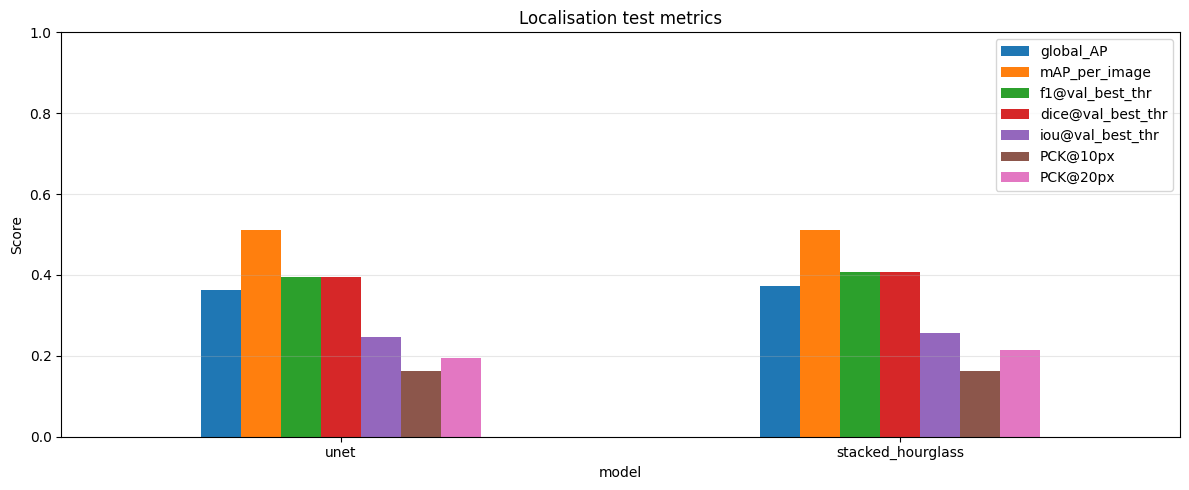

Saved metric comparison figure: C:\Users\Admin\Downloads\riva_outputs\figures\integrated_riva_v4_annotation_audit_improved_v2_localisation_metric_comparison.png


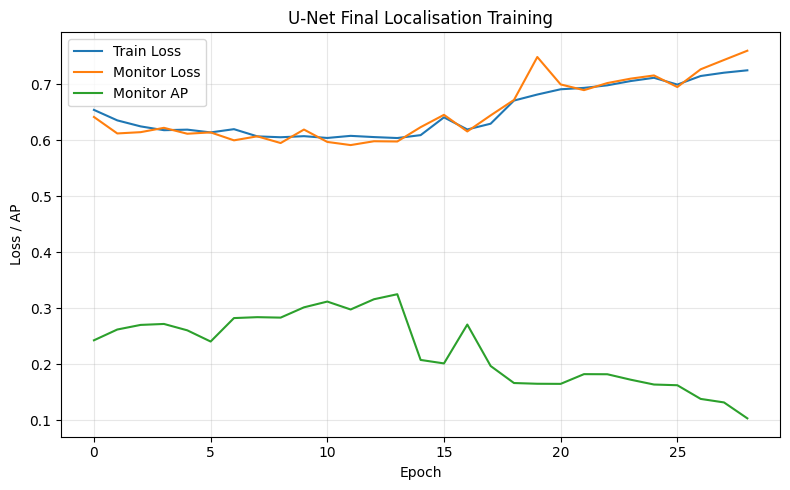

Saved figure: C:\Users\Admin\Downloads\riva_outputs\figures\integrated_riva_v4_annotation_audit_improved_v2_unet_final_localisation_training.png


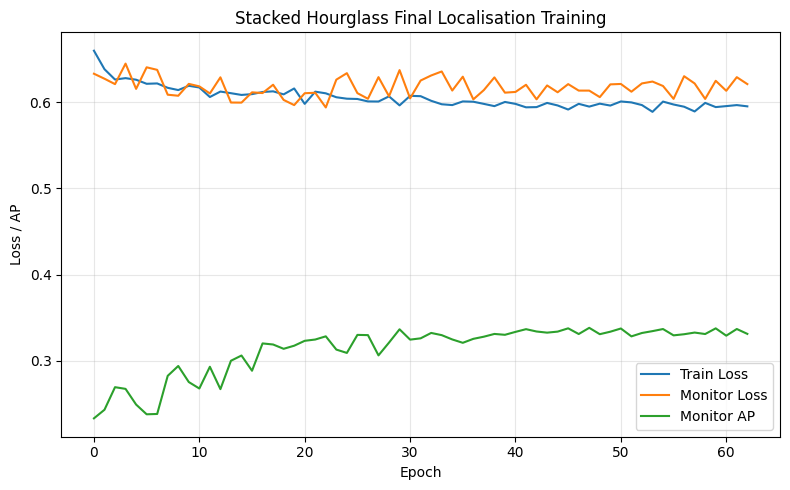

Saved figure: C:\Users\Admin\Downloads\riva_outputs\figures\integrated_riva_v4_annotation_audit_improved_v2_stacked_hourglass_final_localisation_training.png
Raw heatmap-only visualisation skipped here to avoid confusion.
Use the final integrated visualisation cell below: it shows raw heatmap + classifier-gated centre points + cls kept/blocked status.

Best localisation model by mAP/global AP: stacked_hourglass
Saved localisation JSON: C:\Users\Admin\Downloads\riva_outputs\results\integrated_riva_v4_annotation_audit_improved_v2_localisation_results_20260628_145422.json
Saved localisation CSV : C:\Users\Admin\Downloads\riva_outputs\results\integrated_riva_v4_annotation_audit_improved_v2_localisation_results_20260628_145422.csv


In [15]:
def _collect_scores_targets(model, loader, criterion=None, positive_threshold=AP_POSITIVE_THRESHOLD):
    model.eval(); model.to(device)
    total_loss = 0.0
    all_scores, all_targets = [], []
    per_image_ap = []
    peak_distances, pck10, pck20 = [], [], []

    with torch.no_grad():
        for x, hm in loader:
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0).to(device, non_blocking=True)
            hm = torch.nan_to_num(hm, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
            hm_device = hm.to(device, non_blocking=True)
            logits = torch.nan_to_num(model(x), nan=0.0, posinf=30.0, neginf=-30.0)
            if criterion is not None:
                total_loss += criterion(logits, hm_device).item()
            probs = predict_heatmap_probs(model, x, use_tta=EVAL_USE_TTA).detach().cpu().numpy()
            targets = hm.numpy()

            for score_map, target_map in zip(probs, targets):
                score_2d = score_map[0]
                target_2d = target_map[0]
                scores = score_2d.reshape(-1)
                y_true = (target_2d.reshape(-1) >= positive_threshold).astype(np.uint8)
                scores, y_true = _finite_scores_and_targets(scores, y_true)
                if scores.size == 0:
                    continue
                all_scores.append(scores)
                all_targets.append(y_true)
                img_ap = safe_average_precision(y_true, scores)
                if np.isfinite(img_ap):
                    per_image_ap.append(float(img_ap))

                target_2d = np.nan_to_num(target_2d, nan=0.0, posinf=1.0, neginf=0.0)
                score_2d = np.nan_to_num(score_2d, nan=0.0, posinf=1.0, neginf=0.0)
                if target_2d.max() >= positive_threshold:
                    py, px = np.unravel_index(np.argmax(score_2d), score_2d.shape)
                    ty, tx = np.unravel_index(np.argmax(target_2d), target_2d.shape)
                    dist = float(np.sqrt((px - tx) ** 2 + (py - ty) ** 2))
                    peak_distances.append(dist)
                    pck10.append(float(dist <= 10.0))
                    pck20.append(float(dist <= 20.0))

    y_score = np.concatenate(all_scores) if all_scores else np.array([])
    y_true = np.concatenate(all_targets) if all_targets else np.array([])
    avg_loss = total_loss / max(len(loader), 1) if criterion is not None else np.nan
    return y_score, y_true, per_image_ap, peak_distances, pck10, pck20, avg_loss


def _threshold_metrics(y_score, y_true, thr):
    eps = 1e-8
    pred = (y_score >= thr).astype(np.uint8)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    return {
        'precision': float(precision), 'recall': float(recall), 'f1': float(f1),
        'dice': float(dice), 'iou': float(iou), 'tp': tp, 'fp': fp, 'fn': fn,
    }


def find_best_threshold(model, loader, positive_threshold=AP_POSITIVE_THRESHOLD, sweep=THRESHOLD_SWEEP):
    y_score, y_true, *_ = _collect_scores_targets(model, loader, criterion=None, positive_threshold=positive_threshold)
    if y_score.size == 0 or len(np.unique(y_true)) < 2:
        return 0.25, {'f1': np.nan, 'dice': np.nan, 'iou': np.nan, 'precision': np.nan, 'recall': np.nan}
    rows = []
    for thr in sweep:
        m = _threshold_metrics(y_score, y_true, float(thr))
        rows.append({'threshold': float(thr), **m})
    df = pd.DataFrame(rows)
    best = df.sort_values(['f1', 'dice', 'iou'], ascending=False).iloc[0].to_dict()
    return float(best['threshold']), best


def evaluate_localisation_metrics(
    model, loader, criterion, model_name,
    positive_threshold=AP_POSITIVE_THRESHOLD,
    thresholds=METRIC_THRESHOLDS,
    calibrated_threshold=None,
):
    y_score, y_true, per_image_ap, peak_distances, pck10, pck20, test_loss = _collect_scores_targets(
        model, loader, criterion=criterion, positive_threshold=positive_threshold
    )

    global_ap = safe_average_precision(y_true, y_score)
    mean_ap = float(np.mean(per_image_ap)) if per_image_ap else float('nan')

    metrics = {
        'model': model_name,
        'test_loss': float(test_loss),
        'global_AP': global_ap,
        'mAP_per_image': mean_ap,
        'positive_threshold': positive_threshold,
        'target_positive_pixel_fraction': float(np.mean(y_true)) if y_true.size else np.nan,
        'pred_mean': float(np.mean(y_score)) if y_score.size else np.nan,
        'pred_p95': float(np.percentile(y_score, 95)) if y_score.size else np.nan,
        'pred_p99': float(np.percentile(y_score, 99)) if y_score.size else np.nan,
        'pred_max': float(np.max(y_score)) if y_score.size else np.nan,
        'mean_peak_distance_px': float(np.mean(peak_distances)) if peak_distances else np.nan,
        'median_peak_distance_px': float(np.median(peak_distances)) if peak_distances else np.nan,
        'PCK@10px': float(np.mean(pck10)) if pck10 else np.nan,
        'PCK@20px': float(np.mean(pck20)) if pck20 else np.nan,
    }

    for thr in thresholds:
        tm = _threshold_metrics(y_score, y_true, float(thr))
        for k in ['precision', 'recall', 'f1', 'dice', 'iou']:
            metrics[f'{k}@{thr}'] = tm[k]

    if calibrated_threshold is not None:
        tm = _threshold_metrics(y_score, y_true, float(calibrated_threshold))
        metrics['val_calibrated_threshold'] = float(calibrated_threshold)
        for k in ['precision', 'recall', 'f1', 'dice', 'iou']:
            metrics[f'{k}@val_best_thr'] = tm[k]

    return metrics


def plot_localisation_history(history, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.get('train_loss', []), label='Train Loss')
    plt.plot(history.get('monitor_loss', []), label='Monitor Loss')
    if 'monitor_ap' in history:
        plt.plot(history.get('monitor_ap', []), label='Monitor AP')
    plt.xlabel('Epoch')
    plt.ylabel('Loss / AP')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = FIG_DIR_PATH / filename
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {out}')


def visualise_localisation_prediction(model, ds, idx=0, title='Localisation heatmap', filename='localisation_heatmap.png'):
    model.eval(); model.to(device)
    img_t, target_hm = ds[idx]
    with torch.no_grad():
        pred_hm = predict_heatmap_probs(model, img_t.unsqueeze(0).to(device), use_tta=EVAL_USE_TTA).cpu()[0, 0].numpy()
    img_np = np.clip(unnormalize(img_t).permute(1, 2, 0).numpy(), 0, 1)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_np); axes[0].set_title('Input image'); axes[0].axis('off')
    axes[1].imshow(target_hm[0].numpy(), cmap='hot'); axes[1].set_title('Target heatmap'); axes[1].axis('off')
    axes[2].imshow(pred_hm, cmap='hot'); axes[2].set_title(f'Pred heatmap\nmax={pred_hm.max():.3f}'); axes[2].axis('off')
    axes[3].imshow(img_np); axes[3].imshow(pred_hm, cmap='hot', alpha=0.45); axes[3].set_title(title); axes[3].axis('off')
    plt.tight_layout()
    out = FIG_DIR_PATH / filename
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {out}')


# Calibrate thresholds using validation only, then apply those thresholds once on test.
unet_best_thr, unet_val_thr_metrics = find_best_threshold(unet_model, loc_val_loader)
hourglass_best_thr, hourglass_val_thr_metrics = find_best_threshold(hourglass_model, loc_val_loader)
print(f"U-Net validation-best threshold: {unet_best_thr:.2f} | val F1={unet_val_thr_metrics.get('f1', np.nan):.4f}")
print(f"Hourglass validation-best threshold: {hourglass_best_thr:.2f} | val F1={hourglass_val_thr_metrics.get('f1', np.nan):.4f}")

unet_eval = evaluate_localisation_metrics(unet_model, loc_test_loader, criterion, 'unet', calibrated_threshold=unet_best_thr)
hourglass_eval = evaluate_localisation_metrics(hourglass_model, loc_test_loader, criterion, 'stacked_hourglass', calibrated_threshold=hourglass_best_thr)

# Add timing and selected configs to the result table.
unet_eval.update({
    'best_cfg': json.dumps(unet_cfg, sort_keys=True),
    'val_best_threshold_metrics': json.dumps(unet_val_thr_metrics),
    'tune_minutes': float(unet_tune_ckpt.get('elapsed_seconds', 0.0)) / 60.0 if 'unet_tune_ckpt' in globals() else np.nan,
    'final_minutes': float(unet_final_ckpt.get('elapsed_seconds', 0.0)) / 60.0,
})
hourglass_eval.update({
    'best_cfg': json.dumps(hourglass_cfg, sort_keys=True),
    'val_best_threshold_metrics': json.dumps(hourglass_val_thr_metrics),
    'tune_minutes': float(hourglass_tune_ckpt.get('elapsed_seconds', 0.0)) / 60.0 if 'hourglass_tune_ckpt' in globals() else np.nan,
    'final_minutes': float(hourglass_final_ckpt.get('elapsed_seconds', 0.0)) / 60.0,
})

results_df = pd.DataFrame([unet_eval, hourglass_eval])
display(results_df)

metric_cols_for_plot = [
    'global_AP', 'mAP_per_image', 'f1@val_best_thr', 'dice@val_best_thr',
    'iou@val_best_thr', 'PCK@10px', 'PCK@20px'
]
results_df.set_index('model')[metric_cols_for_plot].plot(kind='bar', figsize=(12, 5))
plt.title('Localisation test metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
metric_fig = FIG_DIR_PATH / f'{EXPERIMENT_TAG}_localisation_metric_comparison.png'
plt.savefig(metric_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved metric comparison figure: {metric_fig}')

plot_localisation_history(unet_final_ckpt['history'], 'U-Net Final Localisation Training', f'{EXPERIMENT_TAG}_unet_final_localisation_training.png')
plot_localisation_history(hourglass_final_ckpt['history'], 'Stacked Hourglass Final Localisation Training', f'{EXPERIMENT_TAG}_stacked_hourglass_final_localisation_training.png')
print('Raw heatmap-only visualisation skipped here to avoid confusion.')
print('Use the final integrated visualisation cell below: it shows raw heatmap + classifier-gated centre points + cls kept/blocked status.')

best_loc_name = results_df.sort_values(['mAP_per_image', 'global_AP'], ascending=False).iloc[0]['model']
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
loc_results = {
    'task': 'integrated_classifier_gated_riva_v4_localisation',
    'timestamp': timestamp,
    'experiment_tag': EXPERIMENT_TAG,
    'classifier_integration': {
        'enabled': USE_CLASSIFIER_GATE,
        'mode': CLASSIFIER_GATE_MODE,
        'threshold': CLASSIFIER_GATE_THRESHOLD,
        'classifier_architecture': classifier_architecture,
        'classifier_classes': classifier_classes,
    },
    'labels': LOCALISATION_LABELS,
    'heatmap_size': HEATMAP_SIZE,
    'gaussian_sigma': GAUSSIAN_SIGMA,
    'loss_name': LOC_LOSS_NAME,
    'loss_weights': {
        'pos_weight': LOC_POS_WEIGHT,
        'bce_weight': LOC_BCE_WEIGHT,
        'dice_weight': LOC_DICE_WEIGHT,
        'mse_weight': LOC_MSE_WEIGHT,
        'focal_alpha': FOCAL_ALPHA if 'FOCAL_ALPHA' in globals() else None,
        'focal_gamma': FOCAL_GAMMA if 'FOCAL_GAMMA' in globals() else None,
        'tversky_alpha': TVERSKY_ALPHA if 'TVERSKY_ALPHA' in globals() else None,
        'tversky_beta': TVERSKY_BETA if 'TVERSKY_BETA' in globals() else None,
    },
    'ap_positive_threshold': AP_POSITIVE_THRESHOLD,
    'metric_thresholds': METRIC_THRESHOLDS,
    'threshold_sweep': THRESHOLD_SWEEP.tolist(),
    'batch_size': BATCH_SIZE,
    'tune_epochs': TUNE_EPOCHS,
    'final_epochs': FINAL_EPOCHS,
    'patience': PATIENCE,
    'monitor_metric': MONITOR_METRIC,
    'eval_use_tta': EVAL_USE_TTA,
    'unet_search_space': UNET_SEARCH_SPACE,
    'hourglass_search_space': HOURGLASS_SEARCH_SPACE,
    'models': results_df.to_dict(orient='records'),
    'best_model_by_mAP_per_image_then_global_AP': best_loc_name,
    'checkpoint_dir': str(CHECKPOINT_DIR_PATH),
    'final_model_files': {
        'unet': str(completed_path('unet', 'final')),
        'stacked_hourglass': str(completed_path('stacked_hourglass', 'final')),
    },
}
json_path = RESULTS_DIR_PATH / f'{EXPERIMENT_TAG}_localisation_results_{timestamp}.json'
csv_path = RESULTS_DIR_PATH / f'{EXPERIMENT_TAG}_localisation_results_{timestamp}.csv'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(loc_results, f, indent=2)
results_df.to_csv(csv_path, index=False)

print(f"\nBest localisation model by mAP/global AP: {best_loc_name}")
print(f"Saved localisation JSON: {json_path}")
print(f"Saved localisation CSV : {csv_path}")


## Extra model-comparison metrics table

This section adds a fuller comparison table for U-Net vs Stacked Hourglass. It includes pixel-level heatmap metrics, point-level localisation metrics, classifier-gate behaviour, runtime, and a simple weighted ranking score. Use this table to justify which localisation model is better instead of relying on one visual example.


## Final integrated evaluation and model comparison

Use the tables below to decide which localisation architecture is better. The key table is the final weighted ranking, but the safest academic choice is to discuss both pixel-level metrics and point-level centre-detection metrics.


In [16]:
# Improved point extraction + validation calibration
# This improves the final point result without changing the raw RIVA-style heatmap:
# 1) adaptive threshold = max(base threshold, relative-to-image-max threshold)
# 2) validation search over thresholds/kernels/max points/gate thresholds
# 3) model-specific best settings are used for U-Net and Hourglass comparison

import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

POINT_DISTANCE_THRESHOLDS = [10, 20, 30]
DEFAULT_POINT_MATCH_DISTANCE = 20
POINT_RELATIVE_THRESHOLD = 0.82  # stronger filtering: keep only peaks close to image max


# Compatibility helpers used by calibration / metrics / visualisation
# Some earlier cells define predict_heatmap_probs() and classifier_precancer_probability().
# These wrappers make the later calibration cell safe even if the exact helper names differ.

def predict_raw_heatmap_with_optional_tta(model, images, use_tta=False):
    """Return raw RIVA-v4 localisation probability heatmaps [B,1,H,W].

    The best classification model is NOT allowed to multiply or reshape this heatmap.
    Classification is only used later as a point-level keep/block gate.
    """
    model.eval()
    with torch.no_grad():
        if 'predict_heatmap_probs' in globals():
            raw = predict_heatmap_probs(model, images, use_tta=use_tta, apply_classifier_gate=False)
        else:
            out = model(images)
            if isinstance(out, (tuple, list)):
                out = out[0]
            raw = torch.sigmoid(torch.nan_to_num(out, nan=0.0, posinf=30.0, neginf=-30.0))

            if use_tta:
                preds = [raw]

                x_h = torch.flip(images, dims=[3])
                out_h = model(x_h)
                if isinstance(out_h, (tuple, list)):
                    out_h = out_h[0]
                pred_h = torch.sigmoid(torch.nan_to_num(out_h, nan=0.0, posinf=30.0, neginf=-30.0))
                preds.append(torch.flip(pred_h, dims=[3]))

                x_v = torch.flip(images, dims=[2])
                out_v = model(x_v)
                if isinstance(out_v, (tuple, list)):
                    out_v = out_v[0]
                pred_v = torch.sigmoid(torch.nan_to_num(out_v, nan=0.0, posinf=30.0, neginf=-30.0))
                preds.append(torch.flip(pred_v, dims=[2]))

                raw = torch.stack(preds, dim=0).mean(dim=0)

        raw = torch.nan_to_num(raw, nan=0.0, posinf=1.0, neginf=0.0)
        return raw.clamp(0.0, 1.0)


def get_classifier_probability_for_batch(images):
    """Return PRECANCEROUS probability [B] from the best binary classifier if loaded.

    If no classifier checkpoint is loaded, returns 1.0 so localisation can still be evaluated.
    """
    batch_size = images.shape[0]

    if 'classifier_precancer_probability' in globals():
        try:
            probs = classifier_precancer_probability(images).view(-1)
            return torch.nan_to_num(probs, nan=1.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
        except Exception as e:
            print(f'Classifier helper failed; continuing without gate. Reason: {e}')
            return torch.ones(batch_size, device=images.device)

    if 'binary_classifier' not in globals() or binary_classifier is None:
        return torch.ones(batch_size, device=images.device)

    try:
        binary_classifier.eval()
        with torch.no_grad():
            out = binary_classifier(images)
            if isinstance(out, (tuple, list)):
                out = out[0]

            if out.ndim == 2 and out.shape[1] >= 2:
                pos_idx = globals().get('classifier_positive_index', 1)
                probs = torch.softmax(out, dim=1)[ int(pos_idx)]
            elif out.ndim == 2 and out.shape[1] == 1:
                probs = torch.sigmoid(out[ 0])
            else:
                probs = torch.sigmoid(out.view(batch_size, -1)[ 0])

            return torch.nan_to_num(probs, nan=1.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    except Exception as e:
        print(f'Classifier probability failed; continuing without gate. Reason: {e}')
        return torch.ones(batch_size, device=images.device)


def extract_riva_v4_peaks(
    heatmap,
    threshold=None,
    max_points=None,
    kernel_size=None,
    relative_threshold=POINT_RELATIVE_THRESHOLD,
):
    hm_np = np.asarray(heatmap, dtype=np.float32)
    hm_np = np.nan_to_num(hm_np, nan=0.0, posinf=1.0, neginf=0.0)
    hm_np = np.clip(hm_np, 0.0, 1.0)

    base_thr = HEATMAP_PEAK_THRESHOLD if threshold is None else float(threshold)
    max_points = MAX_DETECTED_POINTS if max_points is None else int(max_points)
    kernel_size = LOCAL_MAX_KERNEL if kernel_size is None else int(kernel_size)

    # This is the key improvement. If the whole heatmap is noisy/high, a fixed 0.45/0.70
    # lets too many blobs survive. Adaptive threshold keeps only peaks near the strongest region.
    adaptive_thr = max(base_thr, float(hm_np.max()) * float(relative_threshold))

    hm = torch.tensor(hm_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    pooled = F.max_pool2d(hm, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    local_max = (hm == pooled) & (hm >= adaptive_thr)
    ys, xs = torch.where(local_max[0, 0])

    points = [(int(x), int(y), float(hm_np[y, x])) for y, x in zip(ys.tolist(), xs.tolist())]
    points = sorted(points, key=lambda p: p[2], reverse=True)
    return points[:max_points]


def predict_integrated_riva_v4_points(
    model,
    images,
    use_tta=False,
    gate_threshold=None,
    heatmap_threshold=None,
    local_max_kernel=None,
    max_detected_points=None,
    relative_threshold=POINT_RELATIVE_THRESHOLD,
):
    raw_heatmaps = predict_raw_heatmap_with_optional_tta(model, images, use_tta=use_tta)
    cls_probs = get_classifier_probability_for_batch(images)
    raw_np = raw_heatmaps.detach().cpu().numpy()

    if gate_threshold is None:
        gate_threshold = CLASSIFIER_GATE_THRESHOLD
    if heatmap_threshold is None:
        heatmap_threshold = HEATMAP_PEAK_THRESHOLD
    if local_max_kernel is None:
        local_max_kernel = LOCAL_MAX_KERNEL
    if max_detected_points is None:
        max_detected_points = MAX_DETECTED_POINTS

    batch_points = []
    for i in range(raw_np.shape[0]):
        cls_prob = float(cls_probs[i].detach().cpu().view(-1)[0])
        if USE_CLASSIFIER_GATE and cls_prob < float(gate_threshold):
            pts = []
        else:
            pts = extract_riva_v4_peaks(
                raw_np[i, 0],
                threshold=heatmap_threshold,
                max_points=max_detected_points,
                kernel_size=local_max_kernel,
                relative_threshold=relative_threshold,
            )
        batch_points.append(pts)
    return raw_heatmaps, batch_points, cls_probs


def _gt_points_for_calibration(ds, ds_idx):
    item = ds.items[ds.indices[ds_idx]]
    return [(float(x), float(y)) for x, y in ds._precancer_points(item) if np.isfinite(x) and np.isfinite(y)]


def _match_points(pred_pts, gt_pts, max_distance=20):
    pred_xy = [(float(p[0]), float(p[1])) for p in pred_pts]
    gt_xy = [(float(p[0]), float(p[1])) for p in gt_pts]
    used_pred = set(); used_gt = set(); distances = []
    candidates = []
    for pi, (px, py) in enumerate(pred_xy):
        for gi, (gx, gy) in enumerate(gt_xy):
            d = float(np.hypot(px - gx, py - gy))
            if d <= max_distance:
                candidates.append((d, pi, gi))
    for d, pi, gi in sorted(candidates, key=lambda x: x[0]):
        if pi in used_pred or gi in used_gt:
            continue
        used_pred.add(pi); used_gt.add(gi); distances.append(d)
    tp = len(distances)
    fp = len(pred_xy) - tp
    fn = len(gt_xy) - tp
    return tp, fp, fn, distances


def calibrate_point_extraction_on_validation(model, ds, model_name, batch_size=LOC_BATCH_SIZE):
    # Cache raw heatmaps and classifier probs once, then sweep cheaply.
    cache = []
    model.eval(); model.to(device)
    for start in range(0, len(ds), batch_size):
        idxs = list(range(start, min(start + batch_size, len(ds))))
        imgs = [ds[i][0] for i in idxs]
        x = torch.stack(imgs).to(device)
        with torch.no_grad():
            raw = predict_raw_heatmap_with_optional_tta(model, x, use_tta=EVAL_USE_TTA).detach().cpu().numpy()
            cls = get_classifier_probability_for_batch(x).detach().cpu().view(-1).numpy()
        for j, ds_idx in enumerate(idxs):
            cache.append({
                'idx': ds_idx,
                'raw': raw[j, 0],
                'cls': float(cls[j]),
                'gt': _gt_points_for_calibration(ds, ds_idx),
            })

    grid = {
        'gate_threshold': [0.00, 0.03, 0.05, 0.10, 0.20],
        'heatmap_threshold': [0.60, 0.70, 0.80, 0.88],
        'kernel': [15, 21, 25, 31],
        'max_points': [4, 6, 8, 12],
        'relative_threshold': [0.75, 0.82, 0.88],
    }

    rows = []
    for gate_thr, hm_thr, kernel, max_pts, rel_thr in itertools.product(
        grid['gate_threshold'], grid['heatmap_threshold'], grid['kernel'], grid['max_points'], grid['relative_threshold']
    ):
        tp = fp = fn = 0; distances = []
        blocked_pos = blocked_empty = empty_images = pos_images = 0
        for rec in cache:
            gt = rec['gt']
            has_gt = len(gt) > 0
            if has_gt:
                pos_images += 1
            else:
                empty_images += 1

            if USE_CLASSIFIER_GATE and rec['cls'] < gate_thr:
                pred = []
                if has_gt:
                    blocked_pos += 1
                else:
                    blocked_empty += 1
            else:
                pred = extract_riva_v4_peaks(rec['raw'], threshold=hm_thr, max_points=max_pts, kernel_size=kernel, relative_threshold=rel_thr)

            m_tp, m_fp, m_fn, m_dist = _match_points(pred, gt, max_distance=DEFAULT_POINT_MATCH_DISTANCE)
            tp += m_tp; fp += m_fp; fn += m_fn; distances.extend(m_dist)

        eps = 1e-8
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        rows.append({
            'model': model_name,
            'gate_threshold': gate_thr,
            'heatmap_threshold': hm_thr,
            'local_max_kernel': kernel,
            'max_detected_points': max_pts,
            'relative_threshold': rel_thr,
            'val_point_precision@20px': precision,
            'val_point_recall@20px': recall,
            'val_point_f1@20px': f1,
            'val_tp@20px': tp,
            'val_fp@20px': fp,
            'val_fn@20px': fn,
            'mean_distance@20px': float(np.mean(distances)) if distances else np.nan,
            'blocked_positive_images': blocked_pos,
            'blocked_empty_images': blocked_empty,
            'positive_images': pos_images,
            'empty_images': empty_images,
        })

    df = pd.DataFrame(rows)
    # Prefer high F1, then fewer blocked positives, then lower distance, then fewer FP.
    best = df.sort_values(
        ['val_point_f1@20px', 'blocked_positive_images', 'mean_distance@20px', 'val_fp@20px'],
        ascending=[False, True, True, True]
    ).iloc[0].to_dict()

    print(f'\nBest point-extraction settings for {model_name}:')
    display(pd.DataFrame([best]))
    return best, df

print('Improved point extraction/calibration functions loaded.')


Improved point extraction/calibration functions loaded.


In [18]:
# FAST calibration run for point extraction settings
# The previous full calibration was taking too long because it swept many
# post-processing combinations over the full validation set for both models.
# This version:
#   1) uses a validation subset,
#   2) disables TTA during calibration,
#   3) caches raw heatmaps once,
#   4) sweeps a smaller grid.
# It does NOT retrain the models.

import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

# Fast calibration settings
FAST_CALIBRATION_MAX_IMAGES = 40      # faster default; increase to 80 only if runtime is okay
FAST_CALIBRATION_BATCH_SIZE = min(16, globals().get('LOC_BATCH_SIZE', 16))
FAST_CALIBRATION_USE_TTA = False      # important: True can double/triple runtime

FAST_HEATMAP_THRESHOLDS = [0.80, 0.85, 0.90]
FAST_RELATIVE_THRESHOLDS = [0.70, 0.75, 0.85]
FAST_LOCAL_MAX_KERNELS = [21, 31]
FAST_MAX_POINTS = [4, 8, 12]
FAST_GATE_THRESHOLDS = [0.00, 0.10, 0.20]

POINT_MATCH_RADIUS = 25

print('Fast calibration settings:')
print(f'  max validation images : {FAST_CALIBRATION_MAX_IMAGES}')
print(f'  batch size            : {FAST_CALIBRATION_BATCH_SIZE}')
print(f'  use TTA               : {FAST_CALIBRATION_USE_TTA}')
print(f'  heatmap thresholds    : {FAST_HEATMAP_THRESHOLDS}')
print(f'  relative thresholds   : {FAST_RELATIVE_THRESHOLDS}')
print(f'  kernels               : {FAST_LOCAL_MAX_KERNELS}')
print(f'  max points            : {FAST_MAX_POINTS}')
print(f'  gate thresholds       : {FAST_GATE_THRESHOLDS}')


def _safe_dataset_item(ds, idx):
    """Return image tensor, target heatmap tensor, metadata dict if available."""
    item = ds[idx]
    if isinstance(item, dict):
        img = item.get('image', item.get('img'))
        hm = item.get('heatmap', item.get('target'))
        meta = item
        return img, hm, meta
    if isinstance(item, (tuple, list)):
        if len(item) == 3:
            img, hm, meta = item
        elif len(item) == 2:
            img, hm = item
            meta = {}
        else:
            raise ValueError(f'Unsupported dataset item length: {len(item)}')
        return img, hm, meta
    raise ValueError(f'Unsupported dataset item type: {type(item)}')


def _gt_points_fast(ds, idx):
    """Get GT points from dataset using the improved annotation method where possible."""
    # Best path: the RIVA dataset object has item list + _precancer_points after annotation fix.
    try:
        item = ds.items[ds.indices[idx]]
        pts = ds._precancer_points(item)
        return [(float(x), float(y)) for x, y in pts if np.isfinite(x) and np.isfinite(y)]
    except Exception:
        pass

    # Metadata path.
    try:
        _, _, meta = _safe_dataset_item(ds, idx)
        pts = meta.get('points', meta.get('keypoints', meta.get('gt_points', [])))
        out = []
        for p in pts:
            if len(p) >= 2:
                x, y = float(p[0]), float(p[1])
                if np.isfinite(x) and np.isfinite(y):
                    out.append((x, y))
        return out
    except Exception:
        pass

    # Last fallback: extract peaks from target heatmap.
    try:
        _, hm, _ = _safe_dataset_item(ds, idx)
        target = hm[0].detach().cpu().numpy() if hasattr(hm, 'detach') else np.asarray(hm)[0]
        pts = extract_riva_v4_peaks(target, threshold=0.50, max_points=30, kernel_size=9)
        return [(float(x), float(y)) for x, y, _ in pts]
    except Exception:
        return []


def match_points_fast(pred_points, gt_points, radius=POINT_MATCH_RADIUS):
    """Greedy one-to-one point matching."""
    if len(pred_points) == 0 and len(gt_points) == 0:
        return 0, 0, 0, []
    if len(pred_points) == 0:
        return 0, 0, len(gt_points), []
    if len(gt_points) == 0:
        return 0, len(pred_points), 0, []

    pred_xy = np.array([[p[0], p[1]] for p in pred_points], dtype=np.float32)
    gt_xy = np.array([[p[0], p[1]] for p in gt_points], dtype=np.float32)

    # Manual distance matrix to avoid scipy dependency.
    diff = pred_xy[:, None, :] - gt_xy[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=2))

    matched_pred = set()
    matched_gt = set()
    matched_distances = []

    while True:
        min_idx = np.unravel_index(np.argmin(dist), dist.shape)
        min_dist = float(dist[min_idx])
        if not np.isfinite(min_dist) or min_dist > radius:
            break

        pred_i, gt_i = int(min_idx[0]), int(min_idx[1])
        if pred_i not in matched_pred and gt_i not in matched_gt:
            matched_pred.add(pred_i)
            matched_gt.add(gt_i)
            matched_distances.append(min_dist)

        dist[pred_i, :] = np.inf
        dist[ gt_i] = np.inf

        if len(matched_pred) == len(pred_points) or len(matched_gt) == len(gt_points):
            break

    tp = len(matched_pred)
    fp = len(pred_points) - tp
    fn = len(gt_points) - tp
    return tp, fp, fn, matched_distances


def extract_adaptive_riva_peaks_fast(
    heatmap,
    base_threshold=0.70,
    relative_threshold=0.60,
    max_points=4,
    kernel_size=21,
):
    """RIVA-style local max extraction with adaptive threshold."""
    hm_np = np.asarray(heatmap, dtype=np.float32)
    hm_np = np.nan_to_num(hm_np, nan=0.0, posinf=1.0, neginf=0.0)
    hm_np = np.clip(hm_np, 0.0, 1.0)

    adaptive_threshold = max(float(base_threshold), float(hm_np.max()) * float(relative_threshold))

    hm = torch.tensor(hm_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    pooled = F.max_pool2d(hm, kernel_size=int(kernel_size), stride=1, padding=int(kernel_size) // 2)
    local_max = (hm == pooled) & (hm >= adaptive_threshold)
    ys, xs = torch.where(local_max[0, 0])

    points = []
    for y, x in zip(ys.tolist(), xs.tolist()):
        points.append((float(x), float(y), float(hm_np[y, x])))

    points = sorted(points, key=lambda p: p[2], reverse=True)
    return points[:int(max_points)]


def fast_cache_validation_predictions(
    model,
    dataset,
    max_images=FAST_CALIBRATION_MAX_IMAGES,
    batch_size=FAST_CALIBRATION_BATCH_SIZE,
    use_tta=FAST_CALIBRATION_USE_TTA,
):
    """Run model once on a validation subset and cache raw heatmaps, classifier scores, and GT points."""
    model.eval()
    model.to(device)

    n = min(len(dataset), int(max_images))
    indices = list(range(n))
    cached = []
    start_time = time.time()

    for start_idx in range(0, n, int(batch_size)):
        batch_indices = indices[start_idx:start_idx + int(batch_size)]

        imgs = []
        for idx in batch_indices:
            img, _, _ = _safe_dataset_item(dataset, idx)
            imgs.append(img)

        x = torch.stack(imgs).to(device)

        with torch.no_grad():
            raw_heatmaps = predict_raw_heatmap_with_optional_tta(model, x, use_tta=use_tta)
            cls_probs = get_classifier_probability_for_batch(x)

        raw_np = raw_heatmaps.detach().cpu().numpy()
        cls_np = cls_probs.detach().cpu().view(-1).numpy()

        for local_i, idx in enumerate(batch_indices):
            try:
                source_item = dataset.items[dataset.indices[idx]]
                image_id = source_item.get('image_id', source_item.get('filename', source_item.get('name', f'idx_{idx}')))
            except Exception:
                _, _, meta = _safe_dataset_item(dataset, idx)
                image_id = meta.get('image_id', meta.get('filename', meta.get('name', f'idx_{idx}')))

            cached.append({
                'idx': idx,
                'image_id': image_id,
                'raw_heatmap': raw_np[local_i, 0],
                'cls_prob': float(cls_np[local_i]),
                'gt_points': _gt_points_fast(dataset, idx),
            })

        done = min(start_idx + int(batch_size), n)
        elapsed = time.time() - start_time
        print(f'Cached {done}/{n} validation images | elapsed {elapsed / 60:.1f} min')

    return cached


def calibrate_point_extraction_fast(model, dataset, model_name, max_images=FAST_CALIBRATION_MAX_IMAGES):
    """Fast validation calibration using cached predictions and a small search grid."""
    print(f'\nFast calibrating {model_name} on max {max_images} validation images...')
    start_time = time.time()

    cached = fast_cache_validation_predictions(
        model,
        dataset,
        max_images=max_images,
        batch_size=FAST_CALIBRATION_BATCH_SIZE,
        use_tta=FAST_CALIBRATION_USE_TTA,
    )

    rows = []
    total_combos = (
        len(FAST_HEATMAP_THRESHOLDS)
        * len(FAST_RELATIVE_THRESHOLDS)
        * len(FAST_LOCAL_MAX_KERNELS)
        * len(FAST_MAX_POINTS)
        * len(FAST_GATE_THRESHOLDS)
    )
    combo_id = 0

    for heat_thr in FAST_HEATMAP_THRESHOLDS:
        for rel_thr in FAST_RELATIVE_THRESHOLDS:
            for kernel in FAST_LOCAL_MAX_KERNELS:
                for max_pts in FAST_MAX_POINTS:
                    for gate_thr in FAST_GATE_THRESHOLDS:
                        combo_id += 1
                        tp_total = fp_total = fn_total = 0
                        blocked_images = kept_images = 0
                        matched_distances_all = []

                        for item in cached:
                            if item['cls_prob'] < float(gate_thr):
                                pred_points = []
                                blocked_images += 1
                            else:
                                pred_points = extract_adaptive_riva_peaks_fast(
                                    item['raw_heatmap'],
                                    base_threshold=heat_thr,
                                    relative_threshold=rel_thr,
                                    max_points=max_pts,
                                    kernel_size=kernel,
                                )
                                kept_images += 1

                            tp, fp, fn, matched_distances = match_points_fast(
                                pred_points,
                                item['gt_points'],
                                radius=POINT_MATCH_RADIUS,
                            )
                            tp_total += tp
                            fp_total += fp
                            fn_total += fn
                            matched_distances_all.extend(matched_distances)

                        precision = tp_total / max(tp_total + fp_total, 1)
                        recall = tp_total / max(tp_total + fn_total, 1)
                        f1 = 2 * precision * recall / max(precision + recall, 1e-8)
                        mean_dist = float(np.mean(matched_distances_all)) if matched_distances_all else np.nan

                        rows.append({
                            'model': model_name,
                            'heatmap_threshold': heat_thr,
                            'relative_threshold': rel_thr,
                            'local_max_kernel': kernel,
                            'max_detected_points': max_pts,
                            'classifier_gate_threshold': gate_thr,
                            'match_radius': POINT_MATCH_RADIUS,
                            'tp': tp_total,
                            'fp': fp_total,
                            'fn': fn_total,
                            'precision': precision,
                            'recall': recall,
                            'f1': f1,
                            'mean_matched_distance_px': mean_dist,
                            'blocked_images': blocked_images,
                            'kept_images': kept_images,
                            'calibration_images': len(cached),
                        })

                        if combo_id % 10 == 0:
                            print(f'{model_name}: checked {combo_id}/{total_combos} combinations')

    df = pd.DataFrame(rows).sort_values(['f1', 'precision', 'recall'], ascending=False).reset_index(drop=True)
    best = df.iloc[0].to_dict()
    best['calibration_minutes'] = (time.time() - start_time) / 60

    print(f'\nBest settings for {model_name}:')
    display(pd.DataFrame([best]))
    print(f'Finished in {best["calibration_minutes"]:.1f} minutes')

    return best, df


# Run fast calibration
unet_point_best, unet_point_calibration_df = calibrate_point_extraction_fast(
    unet_model,
    loc_val_ds,
    'unet',
    max_images=FAST_CALIBRATION_MAX_IMAGES,
)

hourglass_point_best, hourglass_point_calibration_df = calibrate_point_extraction_fast(
    hourglass_model,
    loc_val_ds,
    'stacked_hourglass',
    max_images=FAST_CALIBRATION_MAX_IMAGES,
)

point_calibration_df = pd.concat(
    [unet_point_calibration_df, hourglass_point_calibration_df],
    ignore_index=True,
)

point_calibration_path = RESULTS_DIR_PATH / 'point_extraction_validation_calibration_FAST.csv'
point_calibration_df.to_csv(point_calibration_path, index=False)
print(f'Point calibration table saved to: {point_calibration_path}')

point_best_settings_df = pd.DataFrame([unet_point_best, hourglass_point_best])
print('\nSelected validation-calibrated point settings:')
display(point_best_settings_df)

# Apply U-Net best settings globally as default for visualisation.
# For Hourglass, pass hourglass settings into visualise function if needed.
CLASSIFIER_GATE_THRESHOLD = float(unet_point_best['classifier_gate_threshold'])
CLASSIFICATION_GATE_THRESHOLD = CLASSIFIER_GATE_THRESHOLD
HEATMAP_PEAK_THRESHOLD = float(unet_point_best['heatmap_threshold'])
POINT_RELATIVE_THRESHOLD = float(unet_point_best['relative_threshold'])
LOCAL_MAX_KERNEL = int(unet_point_best['local_max_kernel'])
MAX_DETECTED_POINTS = int(unet_point_best['max_detected_points'])

print('\nApplied U-Net best settings globally:')
print('CLASSIFIER_GATE_THRESHOLD =', CLASSIFIER_GATE_THRESHOLD)
print('HEATMAP_PEAK_THRESHOLD    =', HEATMAP_PEAK_THRESHOLD)
print('POINT_RELATIVE_THRESHOLD  =', POINT_RELATIVE_THRESHOLD)
print('LOCAL_MAX_KERNEL          =', LOCAL_MAX_KERNEL)
print('MAX_DETECTED_POINTS       =', MAX_DETECTED_POINTS)


Fast calibration settings:
  max validation images : 40
  batch size            : 2
  use TTA               : False
  heatmap thresholds    : [0.8, 0.85, 0.9]
  relative thresholds   : [0.7, 0.75, 0.85]
  kernels               : [21, 31]
  max points            : [4, 8, 12]
  gate thresholds       : [0.0, 0.1, 0.2]

Fast calibrating unet on max 40 validation images...
Cached 2/40 validation images | elapsed 0.0 min
Cached 4/40 validation images | elapsed 0.0 min
Cached 6/40 validation images | elapsed 0.0 min
Cached 8/40 validation images | elapsed 0.0 min
Cached 10/40 validation images | elapsed 0.0 min
Cached 12/40 validation images | elapsed 0.0 min
Cached 14/40 validation images | elapsed 0.0 min
Cached 16/40 validation images | elapsed 0.0 min
Cached 18/40 validation images | elapsed 0.0 min
Cached 20/40 validation images | elapsed 0.0 min
Cached 22/40 validation images | elapsed 0.0 min
Cached 24/40 validation images | elapsed 0.0 min
Cached 26/40 validation images | elapsed 0.0 

IndexError: index 8 is out of bounds for axis 0 with size 4

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

CLASSIFIER_GATE_MODE = 'point_gate'
USE_CLASSIFIER_GATE = True
CLASSIFICATION_GATE_THRESHOLD = 0.20
CLASSIFIER_GATE_THRESHOLD = CLASSIFICATION_GATE_THRESHOLD
HEATMAP_PEAK_THRESHOLD = 0.90
RELATIVE_HEATMAP_THRESHOLD = 0.85
POINT_RELATIVE_THRESHOLD = RELATIVE_HEATMAP_THRESHOLD
LOCAL_MAX_KERNEL = 35
MIN_PEAK_DISTANCE = 30
MAX_DETECTED_POINTS = 15
MULTIPLY_HEATMAP_BY_CLASSIFIER = False
USE_GT_COUNT_CAP_FOR_VISUAL_ONLY = False


def suppress_nearby_points(points, min_distance=MIN_PEAK_DISTANCE):
    points = sorted(points, key=lambda p: p[2], reverse=True)
    kept = []

    for x, y, score in points:
        duplicate = False

        for kept_x, kept_y, kept_score in kept:
            distance = ((x - kept_x) ** 2 + (y - kept_y) ** 2) ** 0.5

            if distance < min_distance:
                duplicate = True
                break

        if not duplicate:
            kept.append((x, y, score))

    return kept


def extract_strict_adaptive_peaks(
    heatmap,
    base_threshold=HEATMAP_PEAK_THRESHOLD,
    relative_threshold=RELATIVE_HEATMAP_THRESHOLD,
    kernel_size=LOCAL_MAX_KERNEL,
    max_points=MAX_DETECTED_POINTS,
    min_distance=MIN_PEAK_DISTANCE
):
    hm_np = np.asarray(heatmap, dtype=np.float32)
    hm_np = np.nan_to_num(hm_np, nan=0.0, posinf=1.0, neginf=0.0)
    hm_np = np.clip(hm_np, 0.0, 1.0)

    max_value = float(hm_np.max())

    if max_value <= 0:
        return []

    adaptive_threshold = max(
        float(base_threshold),
        max_value * float(relative_threshold)
    )

    hm = torch.tensor(hm_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    pooled = F.max_pool2d(
        hm,
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size // 2
    )

    local_max = (hm == pooled) & (hm >= adaptive_threshold)
    ys, xs = torch.where(local_max[0, 0])

    points = []

    for y, x in zip(ys.tolist(), xs.tolist()):
        score = float(hm_np[y, x])
        points.append((float(x), float(y), score))

    points = suppress_nearby_points(points, min_distance=min_distance)

    return points[:max_points]


def predict_raw_heatmap_with_optional_tta(model, images, use_tta=False):
    model.eval()

    with torch.no_grad():
        out = model(images)

        if isinstance(out, (tuple, list)):
            out = out[0]

        raw = torch.sigmoid(out)

        if use_tta:
            flipped_images = torch.flip(images, dims=[3])
            flipped_out = model(flipped_images)

            if isinstance(flipped_out, (tuple, list)):
                flipped_out = flipped_out[0]

            flipped_raw = torch.sigmoid(flipped_out)
            flipped_raw = torch.flip(flipped_raw, dims=[3])

            raw = (raw + flipped_raw) / 2.0

        raw = torch.nan_to_num(raw, nan=0.0, posinf=1.0, neginf=0.0)
        raw = raw.clamp(0.0, 1.0)

    return raw


def get_classifier_probability_for_batch(images):
    batch_size = images.shape[0]

    if 'binary_classifier' not in globals() or binary_classifier is None:
        print('Warning: binary_classifier not found. Localisation will run without classifier blocking.')
        return torch.ones(batch_size, device=images.device)

    try:
        binary_classifier.eval()

        with torch.no_grad():
            cls_out = binary_classifier(images)

            if isinstance(cls_out, (tuple, list)):
                cls_out = cls_out[0]

            if cls_out.ndim == 2 and cls_out.shape[1] == 1:
                cls_prob = torch.sigmoid(cls_out[ 0])

            elif cls_out.ndim == 2 and cls_out.shape[1] == 2:
                cls_prob = torch.softmax(cls_out, dim=1)[ 1]

            elif cls_out.ndim == 1:
                cls_prob = torch.sigmoid(cls_out)

            else:
                cls_prob = torch.sigmoid(cls_out.view(batch_size, -1)[ 0])

            cls_prob = torch.nan_to_num(cls_prob, nan=1.0, posinf=1.0, neginf=0.0)

            return cls_prob.clamp(0.0, 1.0)

    except Exception as e:
        print(f'Classifier failed. Localisation will run without classifier blocking. Reason: {e}')
        return torch.ones(batch_size, device=images.device)


def predict_integrated_riva_v4_points(
    model,
    images,
    use_tta=False,
    gate_threshold=CLASSIFICATION_GATE_THRESHOLD,
    heatmap_threshold=HEATMAP_PEAK_THRESHOLD,
    local_max_kernel=LOCAL_MAX_KERNEL,
    max_detected_points=MAX_DETECTED_POINTS,
    relative_threshold=RELATIVE_HEATMAP_THRESHOLD,
    min_peak_distance=MIN_PEAK_DISTANCE,
    max_points=None
):
    model.eval()

    if max_points is not None:
        max_detected_points = max_points

    with torch.no_grad():
        raw_heatmaps = predict_raw_heatmap_with_optional_tta(
            model,
            images,
            use_tta=use_tta
        )

        cls_probs = get_classifier_probability_for_batch(images)

    raw_np = raw_heatmaps.detach().cpu().numpy()
    batch_points = []

    for i in range(raw_np.shape[0]):
        cls_prob = float(cls_probs[i].detach().cpu().item())

        if USE_CLASSIFIER_GATE and cls_prob < gate_threshold:
            points = []
        else:
            points = extract_strict_adaptive_peaks(
                raw_np[i, 0],
                base_threshold=heatmap_threshold,
                relative_threshold=relative_threshold,
                kernel_size=local_max_kernel,
                max_points=max_detected_points,
                min_distance=min_peak_distance
            )

        batch_points.append(points)

    return raw_heatmaps, batch_points, cls_probs


print('Strict integrated point extraction override loaded.')
print('CLASSIFICATION_GATE_THRESHOLD:', CLASSIFICATION_GATE_THRESHOLD)
print('HEATMAP_PEAK_THRESHOLD:', HEATMAP_PEAK_THRESHOLD)
print('RELATIVE_HEATMAP_THRESHOLD:', RELATIVE_HEATMAP_THRESHOLD)
print('LOCAL_MAX_KERNEL:', LOCAL_MAX_KERNEL)
print('MIN_PEAK_DISTANCE:', MIN_PEAK_DISTANCE)
print('MAX_DETECTED_POINTS:', MAX_DETECTED_POINTS)


In [ ]:
# Extra localisation model-comparison metrics table
# Run this after the models are trained/loaded.
# It compares U-Net and Stacked Hourglass using heatmap, point, gate, and runtime metrics.

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display

# Recommended point-gate settings based on the latest visual results.
# Lower classifier gate avoids wrongly blocking LSIL samples.
CLASSIFIER_GATE_THRESHOLD = globals().get('CLASSIFIER_GATE_THRESHOLD', 0.05)
CLASSIFICATION_GATE_THRESHOLD = CLASSIFIER_GATE_THRESHOLD
HEATMAP_PEAK_THRESHOLD = globals().get('HEATMAP_PEAK_THRESHOLD', 0.75)
LOCAL_MAX_KERNEL = globals().get('LOCAL_MAX_KERNEL', 21)
MAX_DETECTED_POINTS = globals().get('MAX_DETECTED_POINTS', 4)
POINT_DISTANCE_THRESHOLDS = [10, 20, 30]

print('Extra comparison settings:')
print(f'  classifier gate threshold : {CLASSIFIER_GATE_THRESHOLD}')
print(f'  heatmap peak threshold    : {HEATMAP_PEAK_THRESHOLD}')
print(f'  local max kernel          : {LOCAL_MAX_KERNEL}')
print(f'  max detected points       : {MAX_DETECTED_POINTS}')
print(f'  point distance thresholds : {POINT_DISTANCE_THRESHOLDS}')


metric_guide_df = pd.DataFrame([
    {
        'metric': 'test_loss',
        'type': 'training/objective',
        'better': 'lower',
        'why_it_matters': 'Checks how well the predicted heatmap matches the target heatmap under the selected loss.'
    },
    {
        'metric': 'global_AP',
        'type': 'pixel ranking',
        'better': 'higher',
        'why_it_matters': 'Measures how well the model ranks positive heatmap pixels above background pixels across the whole test set.'
    },
    {
        'metric': 'mAP_per_image',
        'type': 'pixel ranking',
        'better': 'higher',
        'why_it_matters': 'Average precision per image; prevents one very large/easy image from dominating the result.'
    },
    {
        'metric': 'precision / recall / F1 / Dice / IoU @ threshold',
        'type': 'pixel segmentation',
        'better': 'higher',
        'why_it_matters': 'Checks whether thresholded heatmap regions overlap with target regions. F1/Dice balance precision and recall.'
    },
    {
        'metric': 'point_precision@20px',
        'type': 'point localisation',
        'better': 'higher',
        'why_it_matters': 'Among detected centres, how many are close enough to real annotated keypoints.'
    },
    {
        'metric': 'point_recall@20px',
        'type': 'point localisation',
        'better': 'higher',
        'why_it_matters': 'Among real annotated keypoints, how many were found by the model.'
    },
    {
        'metric': 'point_f1@20px',
        'type': 'point localisation',
        'better': 'higher',
        'why_it_matters': 'Main centre-detection score. Useful because the task is keypoint localisation, not just heatmap colouring.'
    },
    {
        'metric': 'mean_matched_distance_px',
        'type': 'point localisation',
        'better': 'lower',
        'why_it_matters': 'Average distance between matched prediction centres and ground-truth centres.'
    },
    {
        'metric': 'false_positive_points_per_image',
        'type': 'point localisation',
        'better': 'lower',
        'why_it_matters': 'Penalises models that hallucinate too many detected points.'
    },
    {
        'metric': 'blocked_positive_images',
        'type': 'classifier gate',
        'better': 'lower',
        'why_it_matters': 'Counts positive/keypoint images wrongly blocked by the classification gate.'
    },
    {
        'metric': 'blocked_empty_images',
        'type': 'classifier gate',
        'better': 'higher',
        'why_it_matters': 'Counts empty/NILM-style images correctly blocked by the classification gate.'
    },
    {
        'metric': 'tune_minutes / final_minutes',
        'type': 'efficiency',
        'better': 'lower',
        'why_it_matters': 'Shows practical runtime cost. A slightly better model may not be worth much longer training time.'
    },
])

print('\nMetric guide:')
display(metric_guide_df)


def get_ground_truth_points_from_dataset(ds, ds_idx):
    """Return original RIVA annotation points for a dataset sample index.

    This uses the dataset's own _precancer_points() method, so it matches the
    percentage-coordinate handling used to create the target heatmaps.
    """
    try:
        item = ds.items[ds.indices[ds_idx]]
        pts = ds._precancer_points(item)
        clean = []
        for x, y in pts:
            if np.isfinite(x) and np.isfinite(y):
                clean.append((float(x), float(y)))
        return clean
    except Exception:
        # Fallback: extract local maxima from the target heatmap if annotations are unavailable.
        _, hm = ds[ds_idx]
        target = hm[0].detach().cpu().numpy()
        return [(float(x), float(y)) for x, y, _ in extract_riva_v4_peaks(
            target,
            threshold=max(0.50, HEATMAP_PEAK_THRESHOLD),
            max_points=MAX_DETECTED_POINTS,
            kernel_size=LOCAL_MAX_KERNEL,
        )]


def greedy_match_points(pred_points, gt_points, max_distance=20.0):
    """Greedy one-to-one matching between predicted and ground-truth points."""
    pred_xy = [(float(p[0]), float(p[1])) for p in pred_points]
    gt_xy = [(float(g[0]), float(g[1])) for g in gt_points]

    if len(pred_xy) == 0 and len(gt_xy) == 0:
        return 0, 0, 0, []
    if len(pred_xy) == 0:
        return 0, 0, len(gt_xy), []
    if len(gt_xy) == 0:
        return 0, len(pred_xy), 0, []

    candidates = []
    for pi, (px, py) in enumerate(pred_xy):
        for gi, (gx, gy) in enumerate(gt_xy):
            dist = float(np.sqrt((px - gx) ** 2 + (py - gy) ** 2))
            if dist <= max_distance:
                candidates.append((dist, pi, gi))

    candidates.sort(key=lambda x: x[0])
    used_pred, used_gt, matched_distances = set(), set(), []

    for dist, pi, gi in candidates:
        if pi in used_pred or gi in used_gt:
            continue
        used_pred.add(pi)
        used_gt.add(gi)
        matched_distances.append(dist)

    tp = len(matched_distances)
    fp = len(pred_xy) - tp
    fn = len(gt_xy) - tp
    return tp, fp, fn, matched_distances


def evaluate_point_level_metrics(model, ds, model_name, batch_size=LOC_BATCH_SIZE, use_tta=EVAL_USE_TTA):
    """Evaluate classifier-gated centre points against ground-truth keypoints."""
    model.eval(); model.to(device)

    totals = {
        d: {'tp': 0, 'fp': 0, 'fn': 0, 'distances': []}
        for d in POINT_DISTANCE_THRESHOLDS
    }

    image_rows = []
    n = len(ds)

    for start in range(0, n, batch_size):
        batch_indices = list(range(start, min(start + batch_size, n)))
        imgs = []
        gt_points_batch = []
        names = []

        for ds_idx in batch_indices:
            img_t, _ = ds[ds_idx]
            imgs.append(img_t)
            gt_pts = get_ground_truth_points_from_dataset(ds, ds_idx)
            gt_points_batch.append(gt_pts)
            try:
                names.append(ds.items[ds.indices[ds_idx]]['img_name'])
            except Exception:
                names.append(str(ds_idx))

        x = torch.stack(imgs).to(device)

        with torch.no_grad():
            raw_heatmaps, batch_pred_points, cls_probs = predict_integrated_riva_v4_points(
                model, x, use_tta=use_tta, gate_threshold=CLASSIFICATION_GATE_THRESHOLD
            )

        cls_probs_np = cls_probs.detach().cpu().view(-1).numpy()

        for local_i, ds_idx in enumerate(batch_indices):
            pred_pts = batch_pred_points[local_i]
            gt_pts = gt_points_batch[local_i]
            cls_prob = float(cls_probs_np[local_i])
            has_gt = len(gt_pts) > 0
            blocked = cls_prob < CLASSIFICATION_GATE_THRESHOLD

            row = {
                'model': model_name,
                'image_index': ds_idx,
                'image_name': names[local_i],
                'gt_points': len(gt_pts),
                'pred_points': len(pred_pts),
                'cls_prob': cls_prob,
                'blocked_by_classifier_gate': bool(blocked),
                'has_ground_truth_points': bool(has_gt),
            }

            for d in POINT_DISTANCE_THRESHOLDS:
                tp, fp, fn, distances = greedy_match_points(pred_pts, gt_pts, max_distance=float(d))
                totals[d]['tp'] += tp
                totals[d]['fp'] += fp
                totals[d]['fn'] += fn
                totals[d]['distances'].extend(distances)
                row[f'tp@{d}px'] = tp
                row[f'fp@{d}px'] = fp
                row[f'fn@{d}px'] = fn

            image_rows.append(row)

    image_df = pd.DataFrame(image_rows)
    summary = {'model': model_name}

    total_gt = float(image_df['gt_points'].sum()) if len(image_df) else 0.0
    total_pred = float(image_df['pred_points'].sum()) if len(image_df) else 0.0
    summary['images_evaluated'] = int(len(image_df))
    summary['total_gt_points'] = int(total_gt)
    summary['total_pred_points'] = int(total_pred)
    summary['avg_gt_points_per_image'] = float(image_df['gt_points'].mean()) if len(image_df) else np.nan
    summary['avg_pred_points_per_image'] = float(image_df['pred_points'].mean()) if len(image_df) else np.nan

    # Gate behaviour
    gt_pos = image_df[image_df['has_ground_truth_points'] == True]
    gt_empty = image_df[image_df['has_ground_truth_points'] == False]
    summary['mean_cls_prob_gt_positive'] = float(gt_pos['cls_prob'].mean()) if len(gt_pos) else np.nan
    summary['mean_cls_prob_gt_empty'] = float(gt_empty['cls_prob'].mean()) if len(gt_empty) else np.nan
    summary['blocked_positive_images'] = int(gt_pos['blocked_by_classifier_gate'].sum()) if len(gt_pos) else 0
    summary['blocked_empty_images'] = int(gt_empty['blocked_by_classifier_gate'].sum()) if len(gt_empty) else 0
    summary['positive_image_block_rate'] = float(gt_pos['blocked_by_classifier_gate'].mean()) if len(gt_pos) else np.nan
    summary['empty_image_block_rate'] = float(gt_empty['blocked_by_classifier_gate'].mean()) if len(gt_empty) else np.nan

    for d, vals in totals.items():
        tp, fp, fn = vals['tp'], vals['fp'], vals['fn']
        eps = 1e-8
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        distances = vals['distances']
        summary[f'point_precision@{d}px'] = float(precision)
        summary[f'point_recall@{d}px'] = float(recall)
        summary[f'point_f1@{d}px'] = float(f1)
        summary[f'matched_points@{d}px'] = int(tp)
        summary[f'false_positive_points@{d}px'] = int(fp)
        summary[f'missed_gt_points@{d}px'] = int(fn)
        summary[f'mean_matched_distance@{d}px'] = float(np.mean(distances)) if distances else np.nan
        summary[f'median_matched_distance@{d}px'] = float(np.median(distances)) if distances else np.nan
        summary[f'false_positive_points_per_image@{d}px'] = float(fp / max(len(image_df), 1))

    return summary, image_df


# Pixel-level metrics already exist above in results_df. Recompute here if needed.
if 'results_df' not in globals():
    print('results_df not found, recomputing pixel-level metrics...')
    unet_best_thr, unet_val_thr_metrics = find_best_threshold(unet_model, loc_val_loader)
    hourglass_best_thr, hourglass_val_thr_metrics = find_best_threshold(hourglass_model, loc_val_loader)
    unet_eval = evaluate_localisation_metrics(unet_model, loc_test_loader, criterion, 'unet', calibrated_threshold=unet_best_thr)
    hourglass_eval = evaluate_localisation_metrics(hourglass_model, loc_test_loader, criterion, 'stacked_hourglass', calibrated_threshold=hourglass_best_thr)
    results_df = pd.DataFrame([unet_eval, hourglass_eval])

# Point-level metrics based on final classifier-gated detected centres.
unet_point_summary, unet_point_images = evaluate_point_level_metrics(unet_model, loc_test_ds, 'unet')
hourglass_point_summary, hourglass_point_images = evaluate_point_level_metrics(hourglass_model, loc_test_ds, 'stacked_hourglass')
point_metrics_df = pd.DataFrame([unet_point_summary, hourglass_point_summary])
point_image_details_df = pd.concat([unet_point_images, hourglass_point_images], ignore_index=True)

print('\nPoint-level localisation metrics:')
display(point_metrics_df)

# Merge pixel heatmap metrics + point metrics + runtime/config into one comprehensive table.
comparison_df = results_df.merge(point_metrics_df, on='model', how='left', suffixes=('', '_point'))

# Add available timing fields if they were not already included.
if 'tune_minutes' not in comparison_df.columns:
    comparison_df['tune_minutes'] = np.nan
if 'final_minutes' not in comparison_df.columns:
    comparison_df['final_minutes'] = np.nan

# Main metrics table for report/discussion.
preferred_cols = [
    'model',
    'test_loss',
    'global_AP', 'mAP_per_image',
    'val_calibrated_threshold',
    'precision@val_best_thr', 'recall@val_best_thr', 'f1@val_best_thr',
    'dice@val_best_thr', 'iou@val_best_thr',
    'PCK@10px', 'PCK@20px',
    'point_precision@10px', 'point_recall@10px', 'point_f1@10px',
    'point_precision@20px', 'point_recall@20px', 'point_f1@20px',
    'point_precision@30px', 'point_recall@30px', 'point_f1@30px',
    'mean_matched_distance@20px', 'median_matched_distance@20px',
    'false_positive_points_per_image@20px',
    'avg_gt_points_per_image', 'avg_pred_points_per_image',
    'mean_cls_prob_gt_positive', 'mean_cls_prob_gt_empty',
    'blocked_positive_images', 'blocked_empty_images',
    'positive_image_block_rate', 'empty_image_block_rate',
    'tune_minutes', 'final_minutes'
]
existing_cols = [c for c in preferred_cols if c in comparison_df.columns]
full_metric_table_df = comparison_df[existing_cols].copy()

# Round numeric columns for display.
for c in full_metric_table_df.columns:
    if c != 'model' and pd.api.types.is_numeric_dtype(full_metric_table_df[c]):
        full_metric_table_df[c] = full_metric_table_df[c].astype(float).round(4)

print('\nFull model-comparison metrics table:')
display(full_metric_table_df)

# A compact decision table with metric direction and winner.
def pick_winner(df, metric, higher_is_better=True):
    vals = df[['model', metric]].dropna()
    if vals.empty:
        return 'n/a'
    idx = vals[metric].idxmax() if higher_is_better else vals[metric].idxmin()
    return vals.loc[idx, 'model']

selection_metrics = [
    ('mAP_per_image', True, 0.20, 'Main heatmap ranking metric'),
    ('global_AP', True, 0.15, 'Overall pixel ranking metric'),
    ('f1@val_best_thr', True, 0.15, 'Balanced thresholded heatmap metric'),
    ('dice@val_best_thr', True, 0.10, 'Heatmap overlap metric'),
    ('point_f1@20px', True, 0.20, 'Main centre-point localisation metric'),
    ('mean_matched_distance@20px', False, 0.10, 'Lower centre distance is better'),
    ('false_positive_points_per_image@20px', False, 0.05, 'Lower hallucinated points is better'),
    ('positive_image_block_rate', False, 0.05, 'Lower wrongly blocked positive images is better'),
]

selection_rows = []
for metric, higher, weight, reason in selection_metrics:
    if metric not in comparison_df.columns:
        continue
    winner = pick_winner(comparison_df, metric, higher_is_better=higher)
    values = comparison_df.set_index('model')[metric].to_dict()
    row = {
        'metric': metric,
        'better': 'higher' if higher else 'lower',
        'weight': weight,
        'winner': winner,
        'why_used': reason,
    }
    for model_name, value in values.items():
        row[model_name] = value
    selection_rows.append(row)

selection_table_df = pd.DataFrame(selection_rows)
for c in selection_table_df.columns:
    if c not in ['metric', 'better', 'winner', 'why_used'] and pd.api.types.is_numeric_dtype(selection_table_df[c]):
        selection_table_df[c] = selection_table_df[c].astype(float).round(4)

print('\nDecision-support table:')
display(selection_table_df)

# Weighted rank score: converts every selected metric to a 0-1 score, then applies weights.
score_df = comparison_df[['model']].copy()
score_df['weighted_model_score'] = 0.0
score_df['available_weight'] = 0.0

for metric, higher, weight, _ in selection_metrics:
    if metric not in comparison_df.columns:
        continue
    vals = comparison_df[metric].astype(float)
    valid = vals.notna()
    if valid.sum() == 0:
        continue
    min_v, max_v = vals[valid].min(), vals[valid].max()
    if np.isclose(max_v, min_v):
        norm = pd.Series(np.where(valid, 1.0, np.nan), index=comparison_df.index)
    else:
        if higher:
            norm = (vals - min_v) / (max_v - min_v)
        else:
            norm = (max_v - vals) / (max_v - min_v)
    norm = norm.where(valid, np.nan)
    score_df['weighted_model_score'] += norm.fillna(0.0) * weight
    score_df['available_weight'] += valid.astype(float) * weight
    score_df[f'score_component_{metric}'] = norm.round(4)

score_df['weighted_model_score'] = score_df['weighted_model_score'] / score_df['available_weight'].replace(0, np.nan)
score_df['weighted_model_score'] = score_df['weighted_model_score'].round(4)
score_df = score_df.sort_values('weighted_model_score', ascending=False)

print('\nWeighted model ranking:')
display(score_df[['model', 'weighted_model_score', 'available_weight']])

best_model_extra = score_df.iloc[0]['model'] if len(score_df) else 'n/a'
print(f'\nBest model by weighted localisation score: {best_model_extra}')

# Save the extra tables.
timestamp_extra = datetime.datetime.now().strftime('%Y%m%d_%H%M%S') if 'datetime' in globals() else 'latest'
extra_csv = RESULTS_DIR_PATH / f'{EXPERIMENT_TAG}_extra_full_metric_table_{timestamp_extra}.csv'
selection_csv = RESULTS_DIR_PATH / f'{EXPERIMENT_TAG}_extra_decision_table_{timestamp_extra}.csv'
image_details_csv = RESULTS_DIR_PATH / f'{EXPERIMENT_TAG}_extra_point_image_details_{timestamp_extra}.csv'

full_metric_table_df.to_csv(extra_csv, index=False)
selection_table_df.to_csv(selection_csv, index=False)
point_image_details_df.to_csv(image_details_csv, index=False)

print(f'Saved full metric table   : {extra_csv}')
print(f'Saved decision table      : {selection_csv}')
print(f'Saved image-level details : {image_details_csv}')


In [ ]:
# Final integrated visualisation: RIVA v4 heatmap + classifier point gate
# This replaces the confusing raw heatmap-only plot.
# It shows:
#   1) original image
#   2) ground-truth heatmap + GT keypoint centres
#   3) raw localisation heatmap + classifier-gated predicted centres

import numpy as np
import matplotlib.pyplot as plt

# Final recommended settings after checking the latest outputs.
CLASSIFIER_GATE_MODE = 'point_gate'
CLASSIFIER_GATE_THRESHOLD = globals().get('CLASSIFIER_GATE_THRESHOLD', 0.20)
CLASSIFICATION_GATE_THRESHOLD = CLASSIFIER_GATE_THRESHOLD
HEATMAP_PEAK_THRESHOLD = globals().get('HEATMAP_PEAK_THRESHOLD', 0.85)
LOCAL_MAX_KERNEL = globals().get('LOCAL_MAX_KERNEL', 25)
MAX_DETECTED_POINTS = globals().get('MAX_DETECTED_POINTS', 12)
MULTIPLY_HEATMAP_BY_CLASSIFIER = False

print('Final integrated visualisation settings:')
print(f'  classifier gate threshold : {CLASSIFIER_GATE_THRESHOLD}')
print(f'  heatmap peak threshold    : {HEATMAP_PEAK_THRESHOLD}')
print(f'  local max kernel          : {LOCAL_MAX_KERNEL}')
print(f'  max detected points       : {MAX_DETECTED_POINTS}')
print('  integration mode          : classifier gates final points only; heatmap is raw RIVA v4 localisation')


def _safe_gt_points(ds, idx):
    """Get GT keypoint centres for visualisation; fallback to target-heatmap peaks if needed."""
    try:
        item = ds.items[ds.indices[idx]]
        pts = ds._precancer_points(item)
        return [(float(x), float(y)) for x, y in pts if np.isfinite(x) and np.isfinite(y)]
    except Exception:
        try:
            _, hm = ds[idx]
            target = hm[0].detach().cpu().numpy()
            return [(float(x), float(y)) for x, y, _ in extract_riva_v4_peaks(
                target, threshold=0.50, max_points=20, kernel_size=9
            )]
        except Exception:
            return []


def visualise_multiple_integrated_predictions(
    model,
    ds,
    indices=None,
    count=4,
    title='Integrated RIVA v4 localisation',
    filename='integrated_riva_v4_point_gate_examples.png',
    point_settings=None
):
    """Show final integrated localisation output.

    Important:
    - The heatmap is raw RIVA v4-style localisation output.
    - The classifier does NOT multiply or reshape the heatmap.
    - The classifier only keeps/blocks final detected centre points.
    """
    model.eval(); model.to(device)

    if indices is None:
        indices = list(range(min(count, len(ds))))
    else:
        indices = indices[:count]

    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        img_t, target_hm = ds[idx]
        x = img_t.unsqueeze(0).to(device)

        with torch.no_grad():
            settings = point_settings or {}
            raw_heatmaps, batch_points, cls_probs = predict_integrated_riva_v4_points(
                model,
                x,
                use_tta=EVAL_USE_TTA,
                gate_threshold=settings.get('gate_threshold', CLASSIFIER_GATE_THRESHOLD),
                heatmap_threshold=settings.get('heatmap_threshold', HEATMAP_PEAK_THRESHOLD),
                local_max_kernel=settings.get('local_max_kernel', LOCAL_MAX_KERNEL),
                max_detected_points=settings.get('max_detected_points', MAX_DETECTED_POINTS),
                relative_threshold=settings.get('relative_threshold', globals().get('POINT_RELATIVE_THRESHOLD', 0.82)),
            )

        raw_hm = raw_heatmaps.detach().cpu()[0, 0].numpy()
        points = batch_points[0]
        cls_prob = float(cls_probs.detach().cpu().view(-1)[0])
        gt_points = _safe_gt_points(ds, idx)

        img_np = np.clip(unnormalize(img_t).permute(1, 2, 0).numpy(), 0, 1)
        gt_hm = target_hm[0].detach().cpu().numpy()
        img_name = ds.items[ds.indices[idx]].get('img_name', f'idx_{idx}')

        # 1. Input image
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(str(img_name))
        axes[row, 0].axis('off')

        # 2. GT heatmap + GT points
        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(gt_hm, cmap='hot', alpha=0.50)
        if gt_points:
            gx = [p[0] for p in gt_points]
            gy = [p[1] for p in gt_points]
            axes[row, 1].scatter(gx, gy, s=60, marker='x', linewidths=2)
        axes[row, 1].set_title(f'Ground truth: {len(gt_points)} keypoint(s)')
        axes[row, 1].axis('off')

        # 3. Raw prediction heatmap + classifier-gated predicted points
        axes[row, 2].imshow(img_np)
        axes[row, 2].imshow(raw_hm, cmap='hot', alpha=0.50)
        if points:
            px = [p[0] for p in points]
            py = [p[1] for p in points]
            axes[row, 2].scatter(px, py, s=60, marker='x', linewidths=2)
            for x_pt, y_pt, score in points:
                axes[row, 2].text(x_pt + 2, y_pt + 2, f'{score:.2f}', fontsize=7)

        gate_status = 'kept' if cls_prob >= CLASSIFIER_GATE_THRESHOLD else 'blocked'
        axes[row, 2].set_title(
            f'{title}\nraw max={raw_hm.max():.3f}, points={len(points)}, cls={cls_prob:.2f} [{gate_status}]'
        )
        axes[row, 2].axis('off')

    plt.tight_layout()
    out = FIG_DIR_PATH / filename
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved examples: {out}')


# Final example plots. Change indices if you want specific images.
visualise_multiple_integrated_predictions(
    unet_model,
    loc_test_ds,
    count=4,
    title='Integrated U-Net',
    filename='final_integrated_unet_point_gate_examples.png'
)

visualise_multiple_integrated_predictions(
    hourglass_model,
    loc_test_ds,
    count=4,
    title='Integrated Hourglass',
    filename='final_integrated_hourglass_point_gate_examples.png'
)
